# <a id='toc1_'></a>[Bericht zur Datenqualität nach § 12 BKRG](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität nach § 12 BKRG](#toc1_)    
  - [Informationen zum Dokument](#toc1_1_)    
  - [Einführung](#toc1_2_)    
    - [Gesetzliche Grundlagen für den Datensatz des ZfKD und den vorliegenden Bericht](#toc1_2_1_)    
    - [Beschreibung der aktuell am ZfKD verfügbaren Datensätze](#toc1_2_2_)    
      - [Epidemiologischer Datensatz](#toc1_2_2_1_)    
      - [Klinischer Datensatz](#toc1_2_2_2_)    
      - [Unterschiede zwischen ZfKD-Datensatz und oBDS](#toc1_2_2_3_)    
  - [Zusammenarbeit mit den Krebsregistern](#toc1_3_)    
  - [Angaben zur Datenqualität](#toc1_4_)    
    - [Vorbemerkungen und methodische Aspekte](#toc1_4_1_)    
    - [Vollzähligkeit der Erfassung von Krebsneuerkrankungen](#toc1_4_2_)    
    - [Landesspezifische Besonderheiten im aktuellen Datensatz](#toc1_4_3_)    
    - [Informationen zur Diagnose](#toc1_4_4_)    
      - [Anteil fehlendes Grading (wenn Angaben zum Grading erwartet werden)](#toc1_4_4_1_)    
      - [Vollständigkeit der Angaben zum klinischen und pathologischem T-Stadium](#toc1_4_4_2_)    
      - [Vollständigkeit pathologischer T-Stadien bei dokumentierter Operation](#toc1_4_4_3_)    
    - [Informationen zur Therapie](#toc1_4_5_)    
      - [Fälle ohne Therapieangaben](#toc1_4_5_1_)    
      - [Fehlende Angaben zur Operation bei erwartbarer Operation (Brust- Darm-, Hodenkrebs und Malignes Melanom)](#toc1_4_5_2_)    
      - [Fehlende Angaben zur Strahlentherapie bei erwarteter Strahlentherapie (nach brusterhaltender Operation bei Brustkrebs)](#toc1_4_5_3_)    
    - [Fehlende Angaben zur systemischen Therapie bei erwarteter systemischer Therapie (akute Leukämien und hochmaligne Lymphome, Kolonkarzinom Stadium III)](#toc1_4_6_)    
    - [Abstand zwischen Diagnose und erster Operation](#toc1_4_7_)    
    - [Informationen zum Krankheitsverlauf](#toc1_4_8_)    
      - [Nach Brustkrebs](#toc1_4_8_1_)    
      - [Nach Darmkrebs](#toc1_4_8_2_)    
    - [Einordnung der Ergebnisse zur Datenqualität](#toc1_4_9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Informationen zum Dokument](#toc0_)

dolor ipsum dolor sit amet, consectetur adipiscing elit, sed

**Datenstand: Diagnosejahr 2023**

> [!Tip]
> Die angewendeten Filter sind für jede Darstellung ausklappbar

In [1]:
import os
from pathlib import Path
import duckdb as ddb
import pandas as pd
from connection_helper import sql
from pandas_plots import tbl, pls, hlp, const
from enum import Enum
from IPython.display import SVG

os.environ["DY_MAX"] = "2023"  # set before import
from mod.filters import *

os.environ['THEME']='light'
os.environ['DEBUG']='0'
os.environ['RENDERER']="svg"

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
file_db_intern = dir_db/'2025-11-11_internal_clin.duckdb'
file_db_epi = dir_db/'2025-06-20_data_epi.duckdb'
URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

if not file_db_clin.exists():
    raise(FileNotFoundError(f"File {file_db_clin} not found"))

# hlp.show_package_version()
hlp.setup_rendering(True)

In [2]:
sql.print_meta(file_db_clin)
# con.close()

database file:           2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2026-04-14 08:53:41


In [3]:
con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_db_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_intern}' AS internal (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_db_clin}' AS clin (READ_ONLY); SET SCHEMA 'clin';")

Tumor = con.table("Tumor")
Lieferung = con.table("Lieferung")


In [4]:
# _treecompletion = con.table("internal._treecompletion")
dim_tree = sql.load_file_to_duckdb(con, "../quality-reports/data/dim_tree.csv", sep=";")

_treecompletion = (
        con.sql("select *, Diagnose_ICD10_Code_DREI as z_icd10_3d from internal._treecompletion")
        .project('* exclude (Diagnose_ICD10_Code_DREI)')
)
dim_lieferregister = con.table("dim_lieferregister")
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")

In [5]:
with open("../sql/clin_data.sql") as f:
    sql_clin_data = f.read()
db_clin_all = (con
    .sql(sql_clin_data)
    .join(dim_icd10_3d, "z_icd10_3d = code", "left")
    .project("* exclude (code)")
    .project("* replace (bl::tinyint as bl)")
    #.project("* rename (icd10 as z_icd10, icd10_3d as z_icd10_3d)")
)

# tbl.descr_db(db_clin_all, "db_clin_all")

In [6]:
# # ! settings
class grouper_reg(Enum):
    KKR = "kkr"
    SYSTEM = "system"
    TOTAL = "Total"

class kpi(Enum):
    MISSINGS = "kpi_missing"
    UNKNOWN = "kpi_unknown"
    
class grouper_table(Enum):
    TABLECOL = "tablecolumn"
    TABLES = "tables"

DY_MAX = 2023   # fixed value

FILTERS_NO_RP = ("z_kkr <> 7","ohne 07-RP")

# FILTER_TREE_DCO_DY=f"dco=0 and dj_clipped between 2020 and {DY_MAX}"
# FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
# FILTER_DY_DELAY = f"Diagnosedatum between '2020-01-01' and '{DY_MAX}-06-30'"

# FILTER_NO_C44 = "z_icd10_3d not in ('C44','D04')"
# FILTER_NO_DCO = "not z_is_dco"
# FILTER_SOLID = """--sql
#     z_icd10_3d not in ('C44', 'C76', 'C77', 'C78', 'C79')
#     and left(z_icd10_3d,1) = 'C'
#     and right(z_icd10_3d, 2)::int8 <= 80
# """

# FILTER_SYSTEM = """--sql
#     (
#         (left(z_icd10_3d,1) = 'C' and right(z_icd10_3d, 2)::int8 between 81 and 96)
#         OR (left(z_icd10_3d,1) = 'D' and right(z_icd10_3d, 2)::int8 between 45 and 47)
#     )
# """
# FILTER_INSITU = """--sql
#     z_icd10_3d in ('D00', 'D01', 'D02', 'D03', 'D05', 'D06', 'D07', 'D08', 'D09')
# """

# FILTER_C50 = "z_icd10_3d = 'C50'"
# FILTER_M0 = "ifnull(z_m_pc_1,'') <> '1'"
# FILTER_NO_180D_DEAD = "ifnull(z_period_diag_death_day,181) >= 180"

# FILTER_BET = "left(Code,5) in ('5-870')"
# FILTER_R0="upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'"

# FILTER_GRAD = """--sql
#     (
#         left(z_icd10_3d, 1) ='C' and
#         (
#             right(z_icd10_3d, 2)::int8 between 00 and 33
#             or right(z_icd10_3d, 2)::int8 between 50 and 57
#             or right(z_icd10_3d, 2)::int8 between 63 and 68
#             or right(z_icd10_3d, 2)::int8 = 60
#         )
#         and left(Morphologie_Code,4)::int between 8010 and 8576
#     )
# """

# FILTER_TNM = """--sql
#     (
#         left(z_icd10_3d, 1) ='C' and
#         (
#             right(z_icd10_3d, 2)::int8 between 00 and 43
#             or right(z_icd10_3d, 2)::int8 between 45 and 69
#             or right(z_icd10_3d, 2)::int8 between 73 and 74
#         )
#         and left(Morphologie_Code,4)::int between 8010 and 8790
#         and z_icd10_3d not in ('C26', 'C39', 'C55')
#         and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
#     )
# """

# FILTER_AGE_LT_80 = "z_age < 80"
# FILTER_OPS_C50 = "left(Code,4) in ('5-87', '5-88')"
# FILTER_OPS_C18C20 = "left(Code,4) in ('5-45', '5-46', '5-47', '5-48')"
# FILTER_OPS_C62 = "left(Code,4) in ('5-62')"
# FILTER_OPS_C43 = "left(Code,4) in ('5-89', '5-91')"

# FILTER_TOPO = """
#     left(Topographie_Code::text, 3) in ('C26', 'C39', 'C76', 'C80')
#     or Topographie_Code::text in ('C14.0', 'C57.9', 'C63.9', 'C68.9', 'C72.9', 'C75.9')
# """

# FILTER_DY_NO_DCO_C44 = f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_NO_C44}"
# FILTER_DY_SOLID_NO_DCO = f"{FILTER_DY} and {FILTER_NO_DCO} and {FILTER_SOLID}"

## <a id='toc1_2_'></a>[Einführung](#toc0_)

### <a id='toc1_2_1_'></a>[Gesetzliche Grundlagen für den Datensatz des ZfKD und den vorliegenden Bericht](#toc0_)
Mit dem Gesetz zur Zusammenführung von Krebsregisterdaten (2021) wurde auch das Bundeskrebsregisterdatengesetz (BKRG) novelliert. Unter anderem wurde der jährlich aus den Landeskrebsregistern an das Zentrum für Krebsregisterdaten (ZfKD) am Robert Koch-Institut zu übermittelnde Datensatz um wesentliche Elemente der klinischen Krebsregistrierung (Angaben zur Therapie und Krankheitsverlauf) sowie zusätzliche diagnostische Variablen für ausgewählte Diagnosen erweitert. Diese werden in den Krebsregistern je nach Zeitpunkt der landesgesetzlichen Umsetzung des Krebsfrüherkennungs- und Registergesetzes (KFRG 2013) mindestens seit 2019 erfasst. DieDefinition der einzelnen Variablen im Onkologischen Basisdatensatz (oBDS) erfolgt durch die Arbeitsgemeinschaft Deutscher Tumorzentren und den Deutsche Krebsregister e.V. (vormals: Gesellschaft der epidemiologischen Krebsregister in Deutschland) und werden nach § 65c Abs. 1a S. 1 regelmäßig angepasst. 
Um aus dem  für die Meldungen an die  Krebsregister maßgeblichen OBDS im Rahmen der Vorgaben des BKRG einen auswertefähigen Datensatz für die Übermittlung an das ZfKD zu erzeugen, wurde im Jahr 2022 entsprechend § 5 Abs. 3 BKRG in einer Arbeitsgruppe aus Vertretern des ZfKD und den Krebsregistern der „ZfKD-Lieferdatensatz“ vereinbart. 
Der vorliegende Bericht über die Erfahrungen mit der bundesweiten Erfassung von Krebsregisterdaten nach §12 BKRG enthält Angaben zur Datenqualität, zur Zusammenarbeit des ZfKD mit den Krebsregistern und zur Bearbeitung externer Datennutzungsanträge.
### <a id='toc1_2_2_'></a>[Beschreibung der aktuell am ZfKD verfügbaren Datensätze](#toc0_)
Wegen der institutionellen Trennung der (flächendeckenden) epidemiologischen und klinischen Krebsregistrierung in Niedersachsen und Baden-Württemberg, der in den meisten Registern bereits etablierten Schnittstelle für die epidemiologischen Daten  und der unterschiedlich langen verfügbaren Zeitreihen wurde zunächst vereinbart, dass die Register jeweils einen epidemiologischen Datensatz im bisherigen csv-Format (ab erstem verfügbarem Diagnosejahr, je nach Bundesland also mindestens ab 2009) und einen „klinischen Datensatz“ als relationalen Datensatz im xml-Format (für Diagnosen ab 2020) übermitteln. Auf die früher aus einzelnen Bundesländern verfügbaren wenig detaillierten Angaben zur Primärtherapie (z.B. Operation ja/nein) wurde wegen der fehlenden Überführbarkeit in den aktuellen  klinischen Datensatz und der sehr heterogenen Verfügbarkeit und Vollständigkeit  verzichtet. Im ersten Quartal 2023 wurden neben den epidemiologischen Daten erstmals klinische Daten im neuen Datenformat für die Diagnosejahre 2020 und 2021 an das ZfKD übermittelt.

Inhaltlich kann der epidemiologische Datensatz als Teilmenge der klinischen Daten angesehen werden. Unterschiede bestehen bezüglich der Falldefinition: Während für den epidemiologischen Datensatz die internationale gültige Regel gilt, nach der mehrere Tumoren in gleichen Organen oder Organsystemen unter bestimmten Bedingungen (gleicher histologischer Typ) nur einmal gezählt werden, weicht die klinische Falldefinition in einigen Fällen davon ab. So werden zwei Tumoren in paarigen Organen (z.B. Niere, Hoden, Brust) doppelt erfasst, wenn sie beidseitig auftreten, ebenso wird bei zeitlich nacheinander auftretenden in situ und invasiven Tumoren des gleichen Organs und in bestimmten Fällen bei mehreren Darm- und Hauttumoren unterschiedlicher Lokalisation vorgegangen.

#### <a id='toc1_2_2_1_'></a>[Epidemiologischer Datensatz](#toc0_)

Der epidemiologische Datensatz enthält alle Angaben, die in den meisten internationalen bevölkerungsbezogenen Krebsregistern erfasst werden: Angaben zur Diagnose (inkl. monatsgenauem Diagnosedatum, Topographie und Morphologie nach ICD-O, Tumorstadium nach TNM, Differenzierungsgrad sowie Art der Diagnosesicherung) sowie zum monatsgenauen Sterbedatum und zur Todesursache.

#### <a id='toc1_2_2_2_'></a>[Klinischer Datensatz](#toc0_)
Der klinische Datensatz enthält darüber hinaus detaillierte Angaben zur Therapie (Operationen nach OPS-Klassifikation inklusive Residualstatus, Strahlentherapie inkl. Angaben zum Zielgebiet und systemische Therapie einschließlich der verwendeten Medikamente bzw. Protokolle, sowie jeweils monatsgenaue Datumsangaben und tagesgenaue zeitliche Abstände zwischen Diagnose und Therapiebeginn). Für die Strahlentherapie und systemische Therapie ist zudem die Stellung zur OP (adjuvant oder neoadjuvant) angegeben. Therapieangaben betreffen den gesamten Krankheitsverlauf und damit auch Informationen zu Zweit- oder Drittlinientherapien sowie Therapien nach Rezidiven und Progression. Daher handelt es sich technisch im Gegensatz zu den epidemiologischen Daten um einen relationalen Datensatz mit mehreren, auf Tumorebene verknüpfbaren Tabellen. Für ausgewählte Entitäten (bisher: Darm-, Prostata und Brustkrebs sowie malignes Melanom) sind ergänzende Angaben zur Diagnose aus den entsprechenden Modulen des oBDS übernommen worden (u.a. Gleason-Score und prätherapeutischer PSA-Wert beim Prostatakarzinom, Hormonrezeptor- und Her2neu-Status beim Brustkrebs).
#### <a id='toc1_2_2_3_'></a>[Unterschiede zwischen ZfKD-Datensatz und oBDS](#toc0_)

Im Vergleich zum oBDS fehlen in den Daten des ZfKD vor allem Angaben zu den meldenden bzw. behandelnden Einrichtungen, Nebenwirkungen der Therapie, Tumorkonferenzen, zum allgemeinen Leistungszustand (ECOG oder Karnofsky), sowie Gründe für Beendigung einer systemischen Therapie und Strahlendosis. 

## <a id='toc1_3_'></a>[Zusammenarbeit mit den Krebsregistern](#toc0_)
Die Datenlieferung für die klinischen Daten erfolgt nach dem vereinbarten xml-Schema, die epidemiologischen Daten werden nach dem früheren Schema als csv-Dateien übermittelt. Bei jeder Datenlieferung werden jeweils die Daten aus allen Diagnosejahren übermittelt, um Nachmeldungen und Änderungen des Vitalstatus und (bei den klinischen Daten) des Krankheitsverlaufs abbilden zu können. Die Register der ostdeutschen Bundesländer (Berlin/Brandenburg, Mecklenburg-Vorpommern, Sachsen, Sachsen-Anhalt und Thüringen) liefern bisher nur einen klinischen Datensatz ab dem Diagnosejahr 2020, aus dem das ZfKD nach Prüfung auf Mehrfachtumoren (nach epidemiologischer Zählweise) jeweils epidemiologische Datensätze erzeugt. Die aus diesen Ländern am ZfKD verfügbaren epidemiologischen Daten bis einschließlich 2019 stammen noch aus der letzten Datenlieferung des Gemeinsamen Krebsregisters der neuen Bundesländer und Berlins (GKR), das seit Ende 2022 nicht mehr besteht, weshalb der Vitalstatus für diese Fälle bisher noch nicht aktualisiert werden konnte.  Nach Einarbeitung der Daten aus dem Datenbestand des GKR und Aktualisierung des Vitalstatus dieser Fälle (nachträgliche Abgleiche mit den Sterbefällen und Wegzügen in den jeweiligen Bundesländern) werden diese Register voraussichtlich in absehbarer Zeit (mindestens Sachsen-Anhalt schon im kommenden Jahr) in der Lage sein, auch epidemiologische Daten über eine längere Zeitreihe bereitzustellen.
  
Nach eigenem Ermessen und Rücksprache mit dem ZfKD liefern einige Register im Laufe des Jahres aktualisierte Datenstände, häufig mit einer deutlich höheren Fallzahl für das jeweils letzte Diagnosejahr, und tragen damit auch unterjährig zu einer Verbesserung der Datenbasis und Datenqualität bei.

Rückmeldungen an die Register erfolgen mittels automatisierter Qualitätsberichte, die inhaltlich fortlaufend erweitert und mindestens einmal jährlich in Videokonferenzen mit den Registervertretern diskutiert werden. Bei Unklarheiten und Auffälligkeiten erfolgt zusätzlich ein bilateraler Austausch. 
Darüber hinaus nimmt das ZfKD an den alle 6 bis 8 Wochen stattfindenden Treffen der Plattform der klinischen Krebsregister („§65c“) teil und entsendet zwei Vertreter als Mitglied in den Deutsche Krebsregister e.V. (derzeit ein Vertreter im Vorstand). An den vielfältigen Arbeitsgruppen von Plattform und Verein nimmt das ZfKD nur sporadisch teil. Hier wäre eine stärkere Beteiligung sinnvoll, kann aber bisher aus Kapazitätsgründen nicht geleistet werden. Entsprechend hat das ZfKD praktisch keine Ressourcen für eine zentrale Unterstützung der Krebsregister bei übergreifenden Problemstellungen wie den anstehenden Versionswechseln der für die Krebsregistrierung relevanten Klassifikationssysteme (TNM-9, ICD-O-4 und ICD-11).
Die Zusammenarbeit mit den Landeskrebsregistern kann seitens des ZfKD als sehr harmonisch und konstruktiv beschrieben werden. Kooperationen gehen über die reine Datenübermittlung und -prüfung hinaus und betreffen u.a. auch wissenschaftliche Projekte und Vorträge, Drittmittelanträge sowie Gremien- und Öffentlichkeitsarbeit. So ist für 2026 die Bereitstellung eines gemeinsamen interaktiven bundesweiten Datenberichts aus dem ZfKD-Datensatz über die Website des DKR e.V. geplant.

## <a id='toc1_4_'></a>[Angaben zur Datenqualität](#toc0_)
### <a id='toc1_4_1_'></a>[Vorbemerkungen und methodische Aspekte](#toc0_)

Die Prüfung der Qualität der von den Krebsregistern übermittelten Daten sowie entsprechende Rückmeldungen an die Register gehören zu den gesetzlichen Aufgaben des ZfKD. Im Folgenden werden erstmals ausgewählte Auswertungen zur Datenqualität öffentlich bereitgestellt, um auch potentiell Datennutzenden außerhalb der Krebsregistrierung einen ersten Überblick zur Vollständigkeit bestimmter Angaben im Datensatz zu verschaffen. Zukünftig ist mindestens alle zwei Jahre eine Aktualisierung, gegenenfalls mit Erweiterung der entsprechenden Auswertungen, geplant.

Der Fokus der Auswertungen liegt dabei auf der Vollständigkeit von Angaben zur Diagnose (einschließlich Tumorstadien, Differenzierungsgrad) und Therapie, sowie ersten orientierenden Analysen zu Ereignissen im Krankheitsverlauf.  Die hier vorgelegten Auswertungen beziehen sich, mit Ausnahme der Aussagen zur geschätzten Vollzähligkeit der Erfassung, auf den klinischen Datensatz (Diagnosejahre 2020-2023). Nur auf Todesbescheinigungen beruhende Fälle (DCO=death vcertificate only) sowie Fälle mit  nicht-melannotischem Hautkrebs sind ausgeschlossen. Auswertungen zum  epidemiologischen Datensatz, die auch Veränderungen über einen längeren Zeitraum abbilden und Aussagen zur Qualität der Sterbedaten/Angaben zum Vitalstatus beinhalten, werden zu einem späteren Zeitpinkt gesondert veröffentlicht. 

Für Auswertungen zur Vollständigkeit von Therapieangaben wurden Diagnosen aus dem 2. Halbjahr 2023 ausgeschlossen, da Therapiemeldungen häufig deutlich später als Diagnosemeldungen im Krebsregister eingehen. Ausgeschlossen wurden außerdem Personen, die innerhalb von 6 Monaten nach Diagnose verstorben waren, da hier eine eine höhere Wahrscheinlichkeit von Kontraindikationen für eine tumorbezogene Therapie vermutet werden kann. Bei den Operationen wurden alle Prozeduren aus dem Kapitel 5 des OPS berücksichtigt, nur bei den organspezifischen Auswertungen (3.5.2) wurde überprüft, ob der OPS-Kode mit einer tumorresektierenden Operation vereinbar war. Die jeweiligen Filterfunktionen zu den einzelnen Auswertungen sind als eigene Grafiken mit Nennung der Fallzahlen den eigentlichen Abbildungen vorangestellt.

	

### <a id='toc1_4_2_'></a>[Vollzähligkeit der Erfassung von Krebsneuerkrankungen](#toc0_)

Die Vollzähligkeit der Erfassung von Krebserkrankungen (ohne nicht-melanotischem Hautkrebs) wird vom ZfKD lediglich auf Basis des epidemiologischen Datensatzes regelmäßig geschätzt. Nicht berücksichtigt werden Fälle, die den Registern nur über eine Todesbescheinigung oder einen entsprechenden Datenabgleich bekannt werden (DCO-Fälle). Die Schätzung basiert im Kern auf der sogenannten „M/I“ Methode, die in ihrer ursprünglichen Form von einem konstanten Verhältnis der Mortalität zur Inzidenz (M/I), nach Geschlecht, Alter und Diagnose ausgeht. Die Methode der Vollzähligkeitsschätzung war ursprünglich vor allem als Orientierung für neue Register in deren Aufbaujahren konzipiert. Sie wurde im Laufe der Jahre weiterentwickelt und berücksichtigt inzwischen unter bestimmten Bedingungen regionale Abweichungen des Verhältnisses von M/I,  die nach den Ergebnissen aus internationalen und nationalen Studien z.B. in Abhängigkeit von sozioökonomischen Faktoren auf regionaler Ebene auch zu erwarten sind. Dennoch muss betont werden, dass es sich um eine Schätzung mit nicht unerheblichen Unsicherheiten handelt und die Methode mangels Goldstandards in Deutschland noch nicht validiert werden konnte.
Die aktuellen Ergebnisse der Schätzung deuten darauf hin, dass seit mindestens 2020 alle Register eine ausreichende Vollzähligkeit der Erfassung bösartiger Tumorerkrankungen (ohne Berücksichtigung nicht-melanotischer Hautkrebsfälle) nach epidemiologischer Zählweise aufweisen, da jeweils mehr als 90% der aus dem Schätzmodell errechneten erwarteten Fälle erfasst wurden. Für einige Register konnte dieser Wert für das jeweils letzte Lieferdatenjahr erst durch Nachlieferungen im laufenden Jahr erreicht werden, eine ausreichende Vollzähligkeit war in diesen Fällen also erst einige Monate nach dem gesetzlich vorgesehen Lieferdatum gegeben. Wenn man berücksichtigt, dass sich die Frist für die Datenlieferung durch die Register ab 2023 von zwei Jahren auf ein Jahr verkürzt hat, ist dennoch festzustellen, dass sich die Aktualität der im ZfKD verfügbaren Daten in den letzten Jahren deutlich verbessert hat, was eine aktuellere Berichterstattung des ZfKD ermöglicht. 
Teilweise sehr aufwändige Nachrecherche z.B. nur über Sterbe- oder Pathologiemeldungen bekannt gewordener Fälle führen in der Regel zu deutlich verzögert eingehenden Meldungen, die jedoch die Vollzähligkeit und Vollständigkeit der Erfassung verbessern. Daher ist auch in Zukunft damit zu rechnen, dass sich Ergebnisse aus zurückliegenden Jahren nachträglich noch leicht verändern können, was für bevölkerungsbezogene Krankheitsregister generell gilt (Prinzip der „lebenden Datenbanken“).


### <a id='toc1_4_3_'></a>[Landesspezifische Besonderheiten im aktuellen Datensatz](#toc0_)
In Thüringen, Sachsen-Anhalt und Bayern (Regierungsbezirk Oberbayern) ist davon auszugehen, dass Sterbefälle in den aktuellen Jahren (ab 2020 oder später) noch nicht vollständig eingegangen sind, da der entsprechende Datenabgleich zum Zeitpunkt der Datenlieferung noch nicht etabliert war oder sich (in Oberbayern) verzögerte. 
Für Niedersachsen enthält der klinische Datensatz derzeit noch nicht alle Fälle, die im epidemiologischen Datensatz übermittelt wurden.
In Thüringen fehlen im klinischen (und damit auch in den daraus abgeleiteten epidemiologischen Daten ab 2020) derzeit noch etwa 20 - 25% der Fälle, der zugrundeliegende  Fehler (beim Datenexport aus den regionalen Register) wurde inzwischen identifiziert und behoben. Eine probeweise Neulieferung aktueller Diagnosejahre ergab plausible Fallzahlen, so dass der 2026 verfügbare Datensatz (2020-2024) für Thüringen aller Voraussicht nach eine ausreichende Vollzähligkeit aufweisen wird. In Sachsen-Anhalt führte eine abweichende Kodierung der Dignität bei über eine Fernmetastase diagnostizierten Primärtumoren dazu, dass im aktuellen ZfKD-Datensatz knapp 5 Prozent der Fälle aus den aktuellen Jahren fehlen. Auch dies wird bei der kommenden Datenlieferung korrigiert werden. 
Aus Schleswig-Holstein, Niedersachsen, Bremen und dem Saarland wurden dem ZfKD bisher keine Daten zu Verlaufsereignissen und zum Residualstatus übermittelt. Aus Hamburg fehlen Angaben aus allen Organmodulen, in Nordrhein-Westfalen aus dem Prostatamodul, und nur aus sechs Bundesländern liegen Angaben aus dem Modul zum malignen Melanom vor. Dies bedeutet nicht, dass in diesen Ländern keine entsprechenden Informationen vorliegen: in erster Linie liegt  der Grund für die noch bestehenden Lücken in noch nicht umgesetzten „Best-of“-Programmierungen zur Zusammenfassung von Informationen aus mehreren Meldungen entsprechend der ZfKD-Schnittstelle. Diese Lücken sollten sich aller Voraussicht nach in absehbarer Zeit (auch nachträglich für die bereits übermittelten Diagnosejahre) schließen lassen.


### <a id='toc1_4_4_'></a>[Informationen zur Diagnose](#toc0_)
#### <a id='toc1_4_4_1_'></a>[Anteil fehlendes Grading (wenn Angaben zum Grading erwartet werden)](#toc0_)
Der Differenzierungsgrad (Grading)  ist nur für bestimmte Tumoren relevant, die folgenden Auswertung beschränkt sich daher auf Karzinome (ICD-O-3: 81010/3 – 8576/3) und Tumorlokalisationen, bei denen im Falle einer histologischen Sicherung in der Regel eine Angabe zum Grading erwartet werden kann (C00-C33, C50-C57, C60, C62-C68). Prostatakarzinome (C61) wurden hier nicht berücksichtigt, da hier in der Regel der spezifischere Gleason-Score über das entsprechende Modul übermittelt wurde.  Der Anteil fehlender Werte zum Differenzierungsgrad bei den genannten Entiäten lag bundesweit (ohne Rheinland-Pfalz) bei 9%. Für Rheinland Pfalz führte ein Fehler beim Datenexport zu einer sehr hohen Anteil fehlender Werte, dieser Fehler wird bei der nächsten Datenlieferung korrigiert werden.


> [!NOTE]
> _gradingrelevant_: Lokalisationen C00-C33, C50-C57, C60-C68 und Morphologie: 8010-8576
> 
> Kategorien:
>  - `1_null` - kein Wert vorhanden
>  - `2_undefined` - Wert T oder U
>  - `3_rest` - restliche Werte

<!-- START_TOKEN -->

n = 3_241_401                                  (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                   n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur gradingrelevante Tumore]:   n = 997_299  (30.8%) ░░░░░░░░░░░░░░░░░░░░░█████████
└ [ohne 07-RP]:                    n = 949_525  (29.3%) ░░░░░░░░░░░░░░░░░░░░░░████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
and z_kkr <> 7
```

</details>

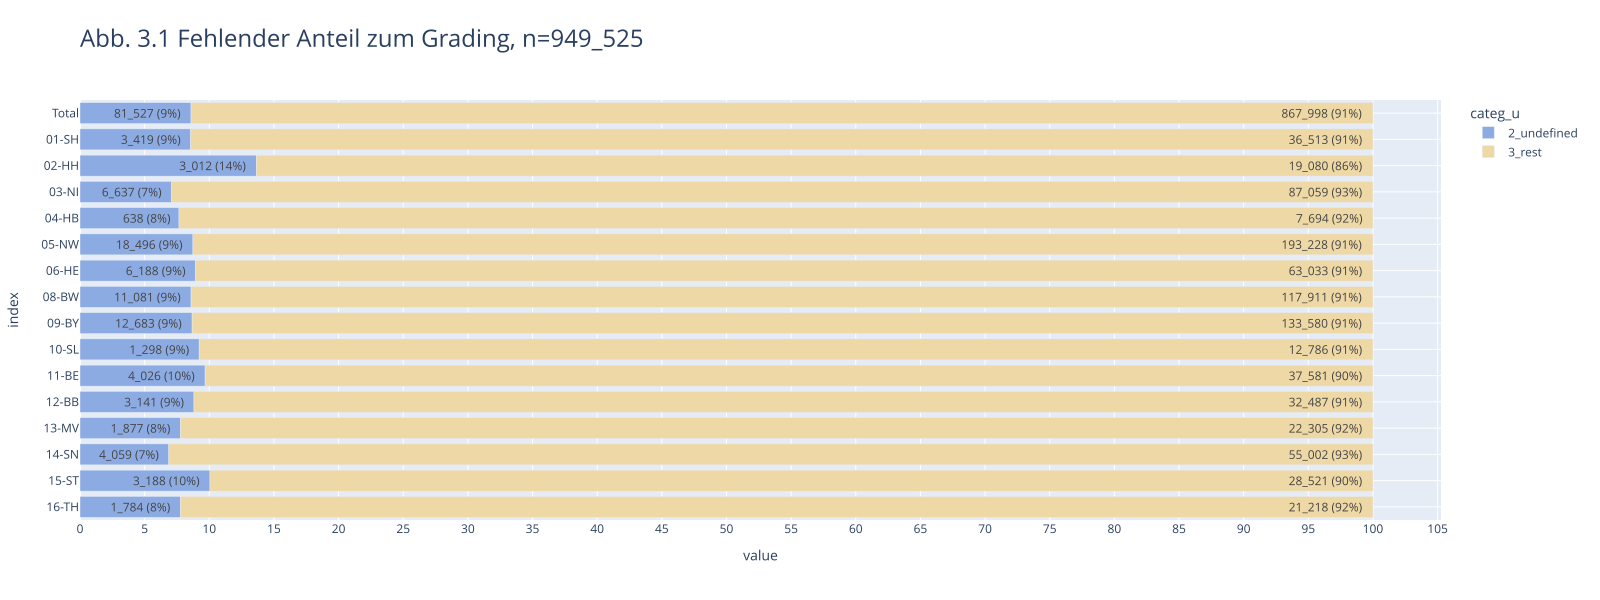

In [7]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_GRAD,
    FILTERS_NO_RP,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_grad=con.sql(f"""--sql
    with t1 as (
        select
            z_kkr_label,
            --Grading,
            case 
                when Grading is null then '1_null'
                when Grading in ('T','U') then '2_undefined'
                else '3_rest' end as categ_u,
        from Tumor
        where {_filter}
    )
    select * from t1
""")

# tbl.descr_db(db_grad, "db_grad")

pls.plot_stacked_bars(
    db_grad.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.1 Fehlender Anteil zum Grading",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label",
    color_palette=const.PALETTE_RKI2,
)

#### <a id='toc1_4_4_2_'></a>[Vollständigkeit der Angaben zum klinischen und pathologischem T-Stadium](#toc0_)
In bundesweit  84% der Fälle mit Diagnosen, für die ein TNM-Stadium in der Regel definiert ist, liegt mindestens ein klinisches (cT) oder pathologisches (pT) T-Stadium vor (Bundesländer: 81%-92%), in 25% sind beide Angaben vorhanden. Aus Rheinland-Pfalz wurde grundsätzlich nur entweder ein pT oder cT übermittelt.

> [!NOTE]
> _tnm-relevant_: Lokalisationen C00-C43, C45-C69, C73-C75 außer: C26, C39, C55, C14.0, C57.9, C63.9, C75.9 und Morphologie: 8010-8790
>
> Kategorien
>  - `1_t_cp` - cT und pT sind vorhanden und nicht `X`
>  - `2_t_c`- cT ist vorhanden und nicht `X`, pT ist leer
>  - `3_t_p`- pT ist vorhanden und nicht `X`, cT ist leer
>  - `4_no_t`- beide leer


<!-- START_TOKEN -->

n = 3_241_401                               (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:             n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur tnm-relevante Tumore]: n = 1_610_344  (49.7%) ░░░░░░░░░░░░░░░░██████████████
└ [ohne 07-RP]:               n = 1_532_637  (47.3%) ░░░░░░░░░░░░░░░░██████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
and z_kkr <> 7
```

</details>

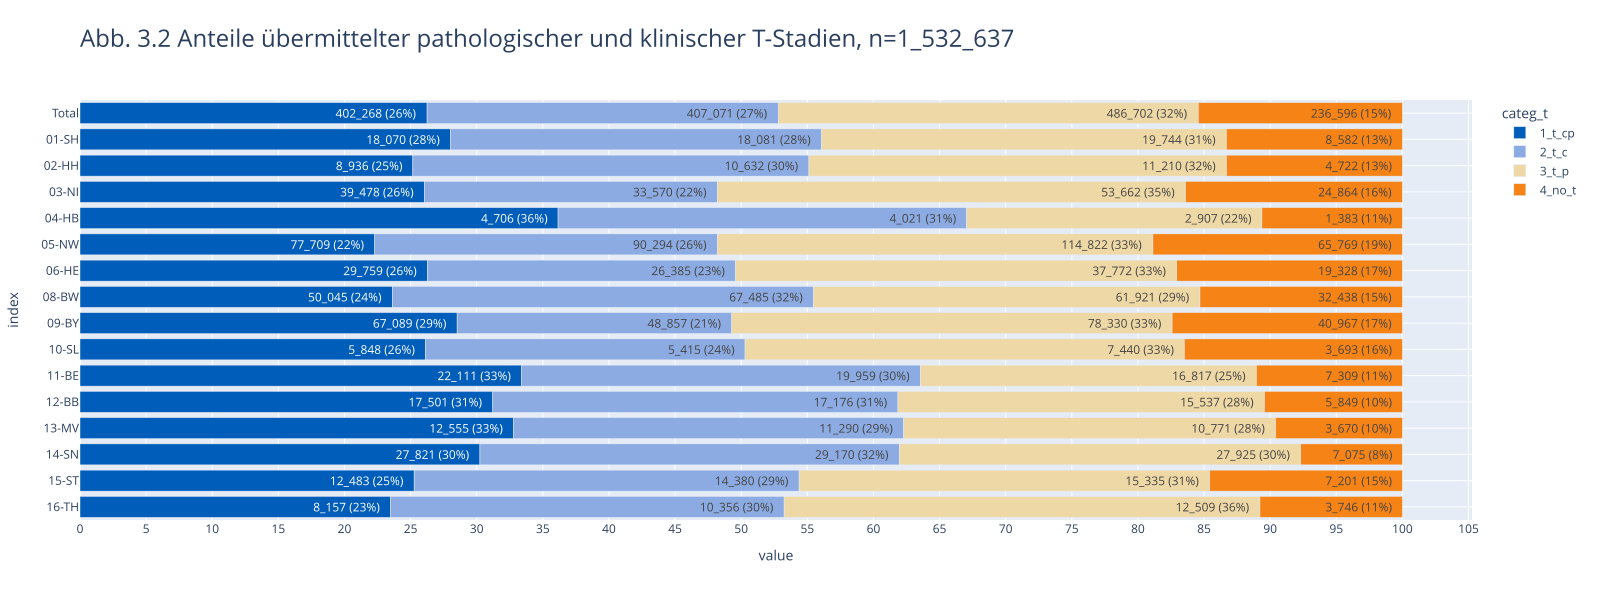

In [8]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_TNM,
    FILTERS_NO_RP,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_t =con.sql(f"""--sql
    select z_kkr_label,
            T_p,
            (T_c is not null and left(T_c, 1) <> 'X') as t_c_present,
            (T_p is not null and left(T_p, 1) <> 'X') as t_p_present,
            case 
                when (T_c is not null and left(T_c, 1) <> 'X') and (T_p is not null and left(T_p, 1) <> 'X') then '1_t_cp'
                when (T_c is not null and left(T_c, 1) <> 'X') and not (T_p is not null and left(T_p, 1) <> 'X') then '2_t_c'
                when not (T_c is not null and left(T_c, 1) <> 'X') and (T_p is not null and left(T_p, 1) <> 'X') then '3_t_p'
                when not (T_c is not null and left(T_c, 1) <> 'X') and not (T_p is not null and left(T_p, 1) <> 'X') then '4_no_t'
                else 'U' end
            as categ_t,
    from Tumor
    where {_filter}
""")
_df = db_t.to_df()
# _=pls.plot_quadrants(_df.iloc[:, 1:3], caption="T_c vs T_p")

pls.plot_stacked_bars(
    _df[["z_kkr_label", "categ_t"]],
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.2 Anteile übermittelter pathologischer und klinischer T-Stadien",
    # color_palette=const.PALETTE_RKI2,
)

#### <a id='toc1_4_4_3_'></a>[Vollständigkeit pathologischer T-Stadien bei dokumentierter Operation](#toc0_)

Nach einer in den Krebsregistern dokumentierten Operation (innerhalb von 6 Monaten nach Diagnose)  ist in 85% der Fälle ein der Tumordiagnose zugeordnetes pathologisches T-Stadium vorhanden (Bundesländer: 74%-93%). Bei Vorhandensein des pT ist bundesweit in 88% auch ein gültiger pathologischer Lymphknotenstatus (pN, ohne pNX) dokumentiert (Bundesländer: 73%-99%, ohne Abbildung).

> [!NOTE]
> _tnm-relevant:_ Lokalisationen C00-C43, C45-C69, C73-C75  außer: C26, C39, C55, C14.0, C57.9, C63.9, C75.9 und mit Morphologie: 8010-8790
>  - `1_null` - kein Wert vorhanden
>  - `2_unknown` - Wert X
>  - `3_rest` - restliche Werte
 

<!-- START_TOKEN -->

n = 3_241_401                                        (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                      n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [keine DCO]:                         n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [nur tnm-relevante Tumore]:          n = 1_610_344  (49.7%) ░░░░░░░░░░░░░░░░██████████████
└ [Tumor hat OP < 180d nach Diagnose]:   n = 835_516  (25.8%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [nur Tumore mit OPS Kap. 5]:           n = 817_684  (25.2%) ░░░░░░░░░░░░░░░░░░░░░░░███████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and not z_is_dco
and 
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 43
            or right(z_icd10_3d, 2)::int8 between 45 and 69
            or right(z_icd10_3d, 2)::int8 between 73 and 74
        )
        and left(Morphologie_Code,4)::int between 8010 and 8790
        and z_icd10_3d not in ('C26', 'C39', 'C55')
        and z_icd10 not in ('C14.0', 'C57.9', 'C63.9')
    )
and z_tum_id in (select distinct z_tum_id from OP where z_period_diag_op_day < 180)
and z_tum_id in (select distinct z_tum_id from OPS where left(ops.Code,1) in ('5'))
```

</details>

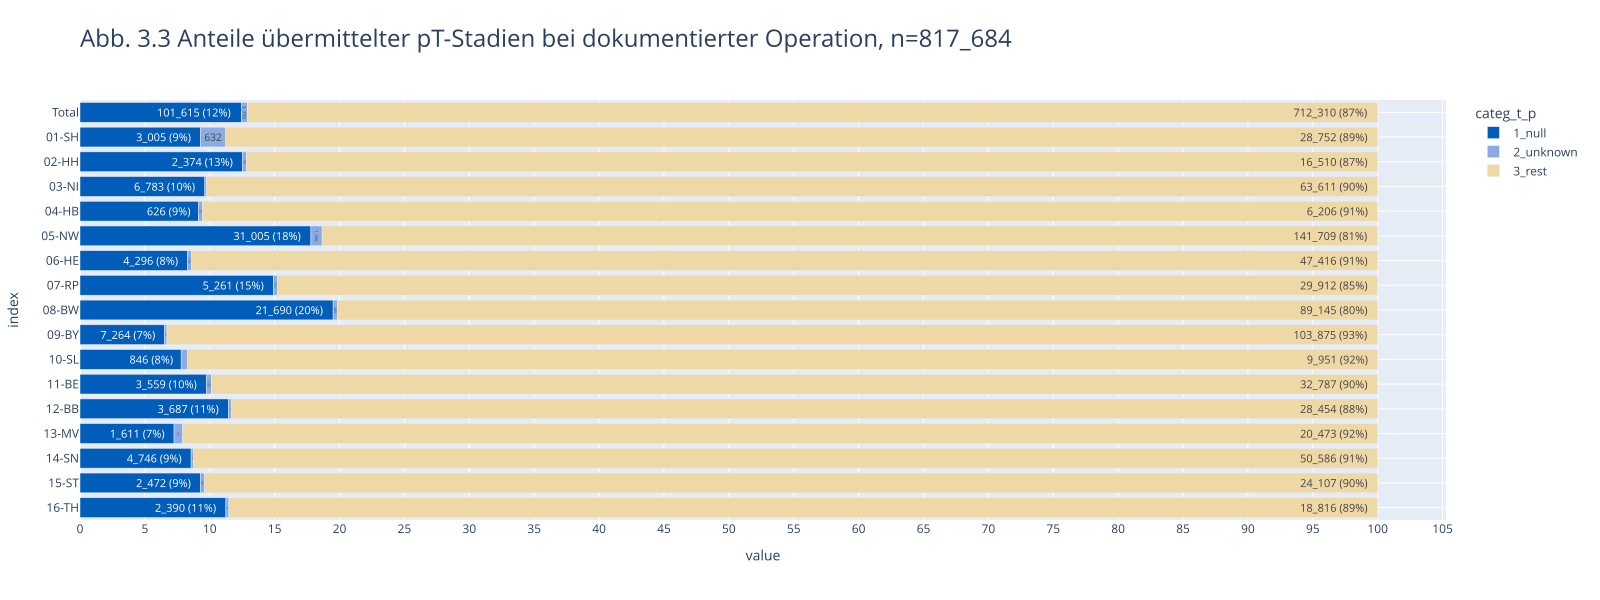

In [9]:
_filters = [
    FILTERS_DY,
    FILTERS_NO_DCO,
    FILTERS_TNM,
    FILTERS_OP_LT_180D,
    # ("z_tum_id in (select distinct z_tum_id from OP where z_period_diag_op_day < 180)","Tumor hat OP < 180d nach Diagnose"),
    # ("z_period_diag_op_day < 180","OP in 180d"),
    ("z_tum_id in (select distinct z_tum_id from OPS where left(ops.Code,1) in ('5'))","nur Tumore mit OPS Kap. 5"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)
db_tnm=con.sql(f"""--sql
    with t2 as (
        select
            z_tum_id,
            z_kkr_label,
            case
                when T_p is null then '1_null'
                when lower(T_p) in ('x') then '2_unknown'
                else '3_rest' end as categ_t_p,
        from Tumor
        where {_filter}
    )
    select * from t2
""")

# tbl.descr_db(db_tnm, "db_tnm")

pls.plot_stacked_bars(
    db_tnm.project("z_kkr_label, categ_t_p").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_tp_has_op",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
    title="Abb. 3.3 Anteile übermittelter pT-Stadien bei dokumentierter Operation"
)

### <a id='toc1_4_5_'></a>[Informationen zur Therapie](#toc0_)
#### <a id='toc1_4_5_1_'></a>[Fälle ohne Therapieangaben](#toc0_)

Der Anteil von Fällen ohne Therapieangaben betrug bundesweit über alle bösartigen Tumorerkrankungen (C00-C97 ohne C44, mit den unter 3.1. genannten Ausschlusskriterien) 23 % (nach Bundesland: 10%-31%). Der Anteil lag in den neuen Bundesländern und Berlin fast durchgehend niedriger (10%-19%) als in den alten Bundesländern (17%-31%) und bei soliden Tumoren (22%) niedriger als bei systemischen Erkrankungen (Leukämien und Lymphome: 35%). Im Zeitverlauf ist zwischen 2020 und 2022 keine Tendenz zu beobachten. Trotz Ausschluss der Diagnosen im 2. Halbjahr 2023 liegt der Anteil von Fällen ohne Therapieangabenin 2023 noch etwas über dem Wert der Vorjahre, auch hier ist wahrscheinlich noch mit nachträglichen Ergänzungen zu rechnen.


<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 nur C]:                   n = 2_207_903  (68.1%) ░░░░░░░░░░████████████████████
└ [keine DCO]:                     n = 2_129_378  (65.7%) ░░░░░░░░░░░███████████████████
└ [keine C44,D04]:                 n = 1_736_942  (53.6%) ░░░░░░░░░░░░░░████████████████
└ [keine Verstorbenen < 180 Tage]: n = 1_486_572  (45.9%) ░░░░░░░░░░░░░░░░░█████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and left(z_icd10_3d,1) = 'C'
and not z_is_dco
and z_icd10_3d not in ('C44','D04')
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

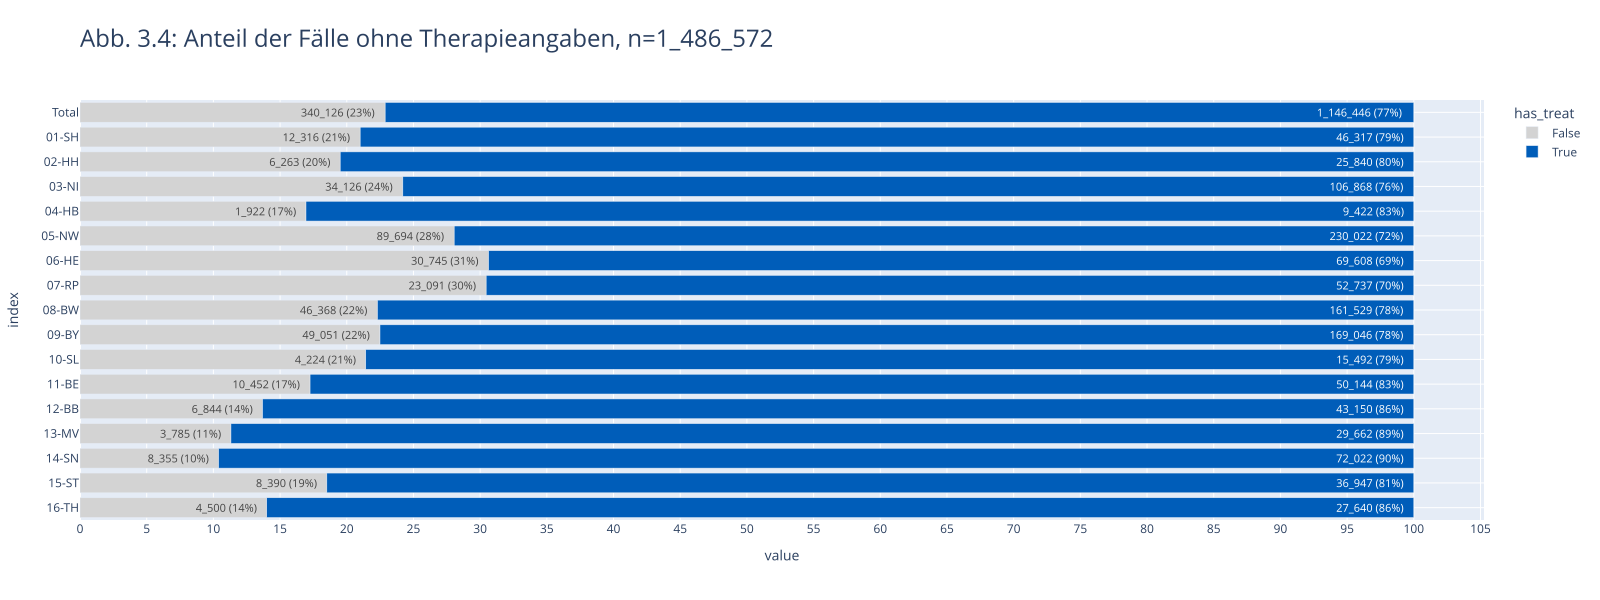

In [10]:

_filters = [
    # FILTERS_DY,
    FILTERS_DY_DELAY,
    FILTERS_C,
    FILTERS_NO_DCO,
    FILTERS_NO_C44,
    FILTERS_NO_180D_DEAD,
    # FILTERS_NO_SOLID,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_miss = con.sql(f"""--sql
    select
        z_tum_id,
        z_kkr_label,
        --z_dy::text as z_dy,
        z_tum_op_count,
        z_tum_st_count,
        z_tum_sy_count,
        case when z_tum_op_count + z_tum_st_count + z_tum_sy_count > 0 then true else false end as has_treat,
        Diagnosedatum,
    from Tumor
    where true
    and {_filter}
""")
# tbl.descr_db(db_miss, "db_miss")
pls.plot_stacked_bars(
    db_miss.project("z_kkr_label, has_treat").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    first_col_grey=True,
    title="Abb. 3.4: Anteil der Fälle ohne Therapieangaben"
)

#### <a id='toc1_4_5_2_'></a>[Fehlende Angaben zur Operation bei erwartbarer Operation (Brust- Darm-, Hodenkrebs und Malignes Melanom)](#toc0_)
In den folgenden Auswertungen wurden zusätzlich zu den unter 3.1. genannten Fällen auch noch solche mit primärer Fernmetastasierung ausgeschlossen. Für Fälle ohne dokumentierte, das jeweilige Organ betreffende Operation (ohne Berücksichtigung diagnostischer Eingriffe) wurde zusätzlich ausgewertet, ob ein gültiges pathologisches T-Stadium (pT) vorlag, was als Hinweis auf eine fehlende oder unvollständige klinische Meldung interpretiert werden kann. 

Nach Brustkrebsdiagnose liegen bundesweit in 25% (nach Bundesländern: 9%-32%) keine Angaben zu einer Operation an der Brust vor. Bei etwa einem Drittel dieser Fälle ist ein pT vorhanden. Der Anteil von Fällen ohne dokumentierte Operation sinkt bei Ausschluss älterer Patientinnen (über 80 Jahre) von 25% auf 23%.
Nach dokumentierten Operationen war ein R-Status in 98% der Fälle mit R0-2 angegeben (Bundesländer: 95%-99%), unter den sonstigen Fällen sind fehlende Befunde aufgrund nicht beurteilbarer Präparate (RX) eingerechnet (ohne Abbildung).

> [!CAUTION]
> berücksichtigt sind UICC I-III
>
> Kategorien
>  - `1_op`: mind. eine OPS im definierten Bereich (3Steller, organspezifisch) ist dokumentiert
>  - `2_no_op_but_tp`: keine OPS, aber pT 1-4 ist dokumentiert
>  - `3_rest`: keine der zuvor genannten Merkmale trifft zu

<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C50]:                       n = 316_685   (9.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [kein M1]:                         n = 295_287   (9.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [keine Verstorbenen < 180 Tage]:   n = 283_195   (8.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C50'
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

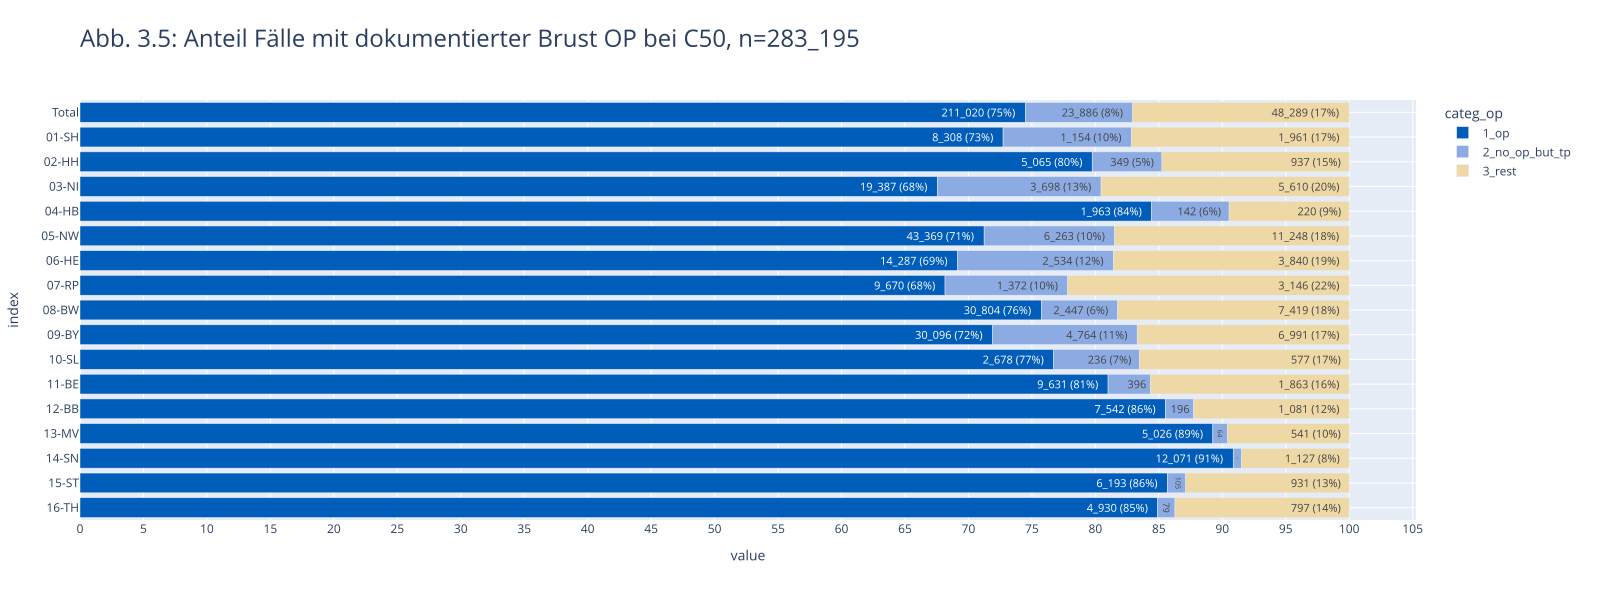

In [11]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and {FILTER_C50}"

_filters = [
    FILTERS_DY,
    FILTERS_C50,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C50[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.5: Anteil Fälle mit dokumentierter Brust OP bei C50",
)

Beim Darmkrebs (C18-C20) liegen bundesweit in 32% (nach Bundesländern: 10%-41%) keine Angaben zu einer Darmoperation vor. In rund der Hälfte dieser Fälle ist ein pT vorhanden. Der Anteil von Fällen ohne dokumentierte Operation sinkt bei Ausschluss älterer Patientinnen und Patienten (>80 Jahre) auf 31%. 

<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C18-C20]:                   n = 226_382   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [kein M1]:                         n = 187_563   (5.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 161_924   (5.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C18', 'C19', 'C20')
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

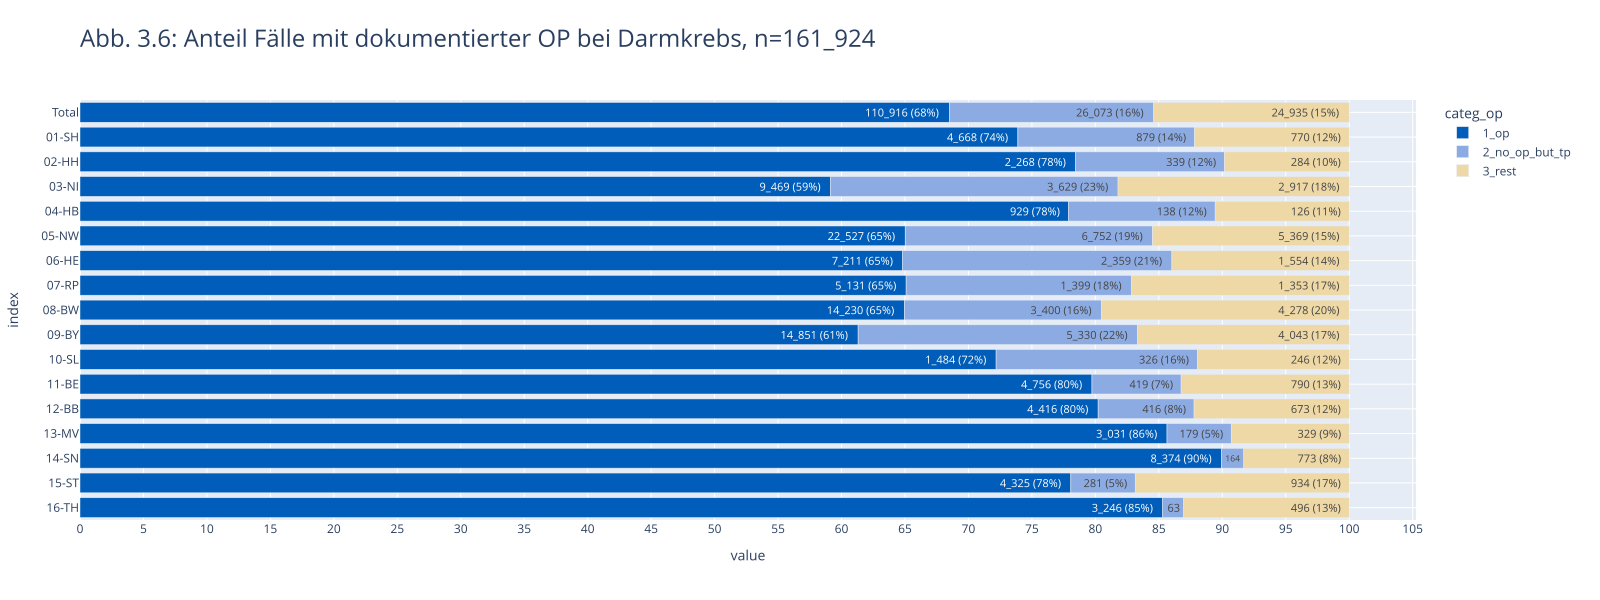

In [12]:

# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C18', 'C19', 'C20')"

_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c18 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C18C20[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c18.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.6: Anteil Fälle mit dokumentierter OP bei Darmkrebs",
)

Beim Malignen Hautmelanom (C43) liegen bundesweit in 42% (nach Bundesländern: 3%-77%) keine Angaben zu einer zur Diagnose passenden Operation vor. In rund 80% dieser Fälle ist ein pT vorhanden. Auch nach Ausschluss älterer am Melanom erkrankter Personen (>80 Jahre) liegt der Anteil von Fällen ohne dokumentierte Operationen bei 42%.


<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [C43]:                             n = 110_067   (3.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 107_527   (3.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:   n = 104_913   (3.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d = 'C43'
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

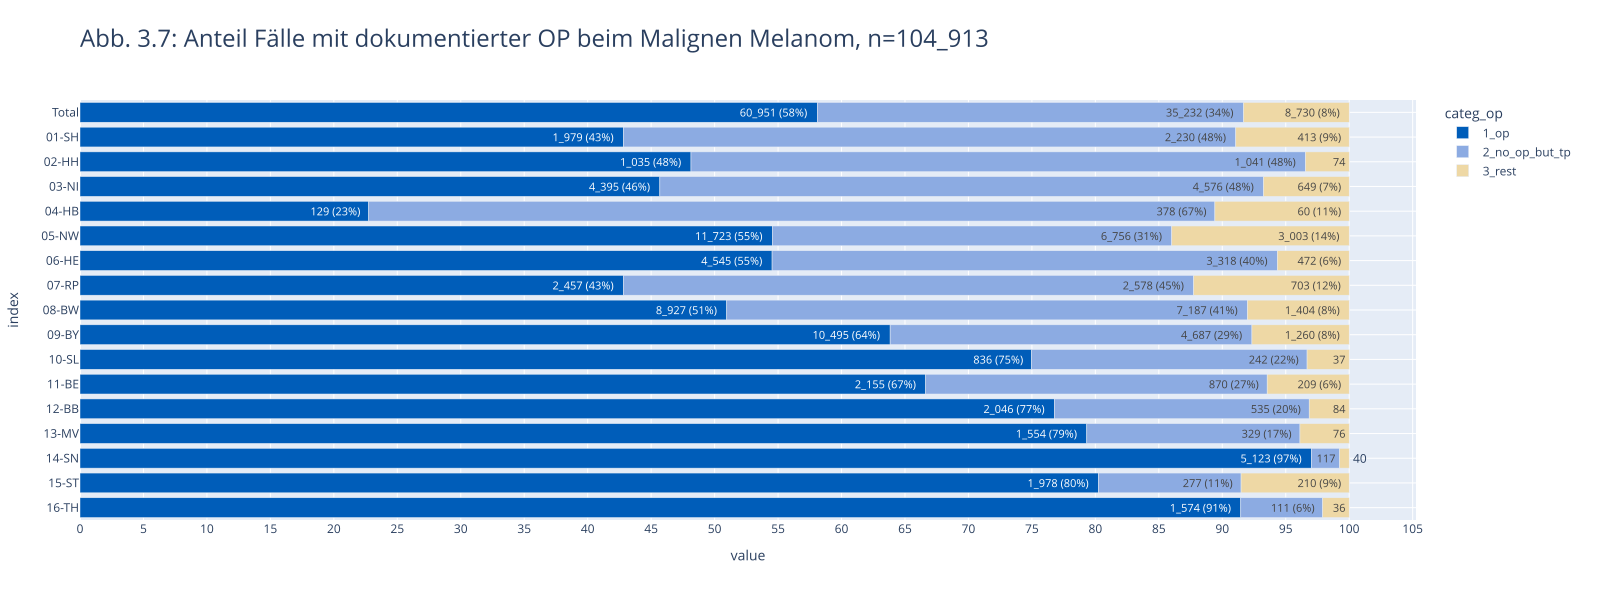

In [13]:
_filters = [
    FILTERS_DY,
    ("z_icd10_3d = 'C43'","C43"),
    FILTERS_NO_M1,
    # FILTERS_M0,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c43 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C43[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)

pls.plot_stacked_bars(
    db_op_c43.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.7: Anteil Fälle mit dokumentierter OP beim Malignen Melanom",
)

Beim Hodenkrebs (C62) liegen bundesweit in 30% (nach Bundesländern: 4%-46%) keine Angaben zu einer Hodenoperation vor. In rund 80% dieser Fälle ist ein pT vorhanden. Auch nach Ausschluss älterer Hodenkrebspatienten (>80 Jahre) liegt der Anteil von Fällen ohne dokumentierte Operationen bei 30%.


<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023]:                  n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [ICD10 C62]:                        n = 16_882   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [kein M1]:                          n = 15_892   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 15_657   (0.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_icd10_3d in ('C62')
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

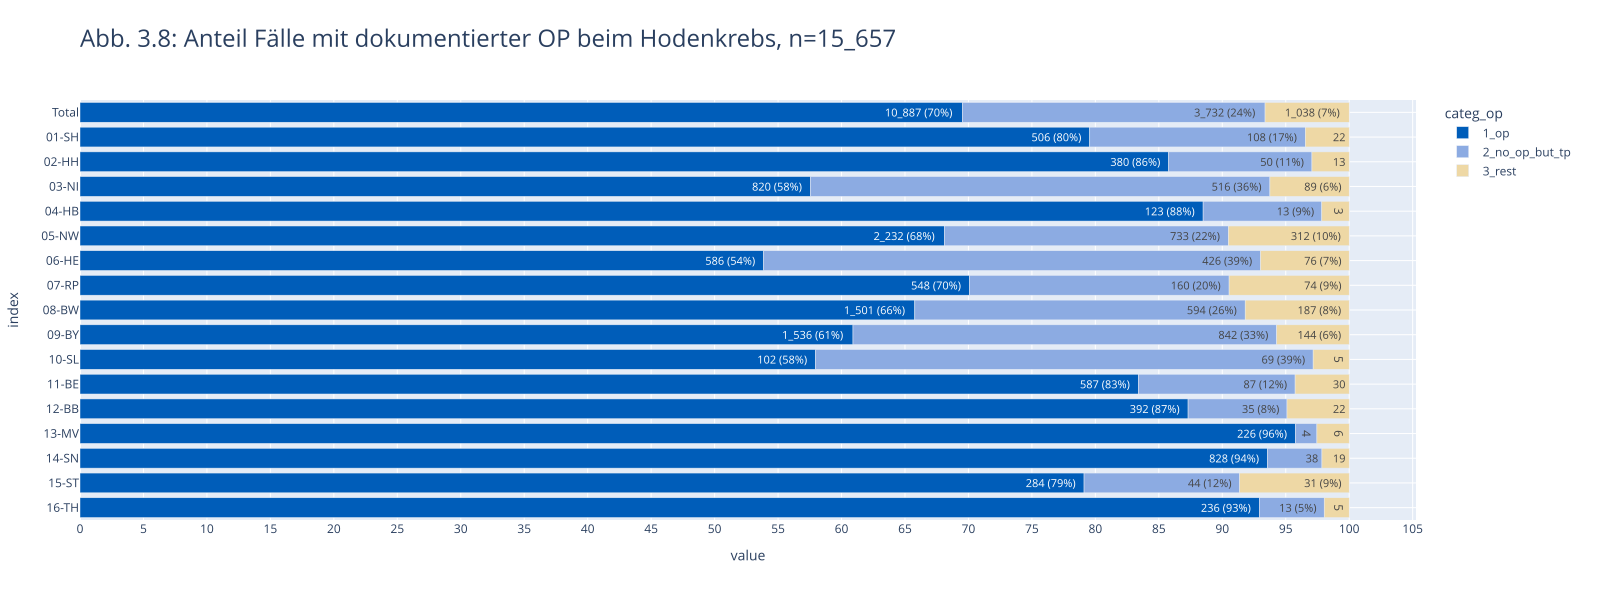

In [14]:
# FILTER = f"{FILTER_NO_180D_DEAD} and {FILTER_M0} and {FILTER_DY} and z_icd10_3d in ('C62')"

_filters = [
    FILTERS_DY,
    ("z_icd10_3d in ('C62')", "ICD10 C62"),
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_op_c50 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            op.Intention,
            z_tum_op_count,
            z_tum_st_count,
            z_tum_sy_count,
            case when {FILTERS_OPS_C62[0]} then true else false end as has_ops,
            case when z_t_p_1 in ('1','2','3','4') then true else false end as has_t_p,
            case when st.Stellung_OP = 'O' or sy.Stellung_OP = 'O' then true else false end as has_stell_op,
            sy.SYSTId
        from Tumor tum
        left join op on op.z_tum_id = tum.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join ST st on tum.z_tum_id = st.z_tum_id
        left join SYST sy on tum.z_tum_id = sy.z_tum_id
        where {_filter}
    ),
    t2 as (
        select
            z_tum_id,
            any_value(z_kkr_label) as z_kkr_label,
            case
                when max(has_ops) then '1_op'
                when max(has_t_p) then '2_no_op_but_tp'
                --when max(has_stell_op) then '3_no_op_tp_but_other'
                when not(max(has_ops and has_t_p and has_stell_op)) then '3_rest'
                else 'U'
            end as categ_op,
            --Intention,
        from t1
        group by z_tum_id
    )
    select * from t2
""")
# tbl.descr_db(db_op_c50, "db_op_c50")
# db_op_c50.filter("z_tum_id = 'cdb36878-a43c-4413-9b56-14220b042323'").show()
# db_op_c50.filter("left(categ_op,1) = '4'").show()
# hlp.get_tum_details("c46d2307-ff1d-4dae-9725-d1e558dbd49f",con=con)


pls.plot_stacked_bars(
    db_op_c50.project("z_kkr_label, categ_op").to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.8: Anteil Fälle mit dokumentierter OP beim Hodenkrebs",
)

#### <a id='toc1_4_5_3_'></a>[Fehlende Angaben zur Strahlentherapie bei erwarteter Strahlentherapie (nach brusterhaltender Operation bei Brustkrebs)](#toc0_)
Nach brusterhaltender Operation eines bösartigen Tumors der Brust liegen bundesweit in 33% (nach Bundesländern: 13%-54%) keine Angaben zu einer Strahlentherapie vor. Bei etwas mehr als der Hälfte dieser Fälle ist auch keine systemische Therapie dokumentiert, dies betrifft bundesweit insgesamt 18% der Fälle. 

> [!NOTE]
> Brusterhaltende Therapie (BET): ein OPS Code mit den ersten 5 Stellen `5-870` liegt vor

<!-- START_TOKEN -->

count: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 C50]:                       n = 278_699   (8.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [kein M1]:                         n = 259_569   (8.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [nur OPS für BET]:                 n = 144_136   (4.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine Verstorbenen < 180 Tage]:   n = 143_832   (4.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10_3d = 'C50'
and ifnull(z_m_pc_1,'') <> '1'
and left(Code,5) in ('5-870')
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

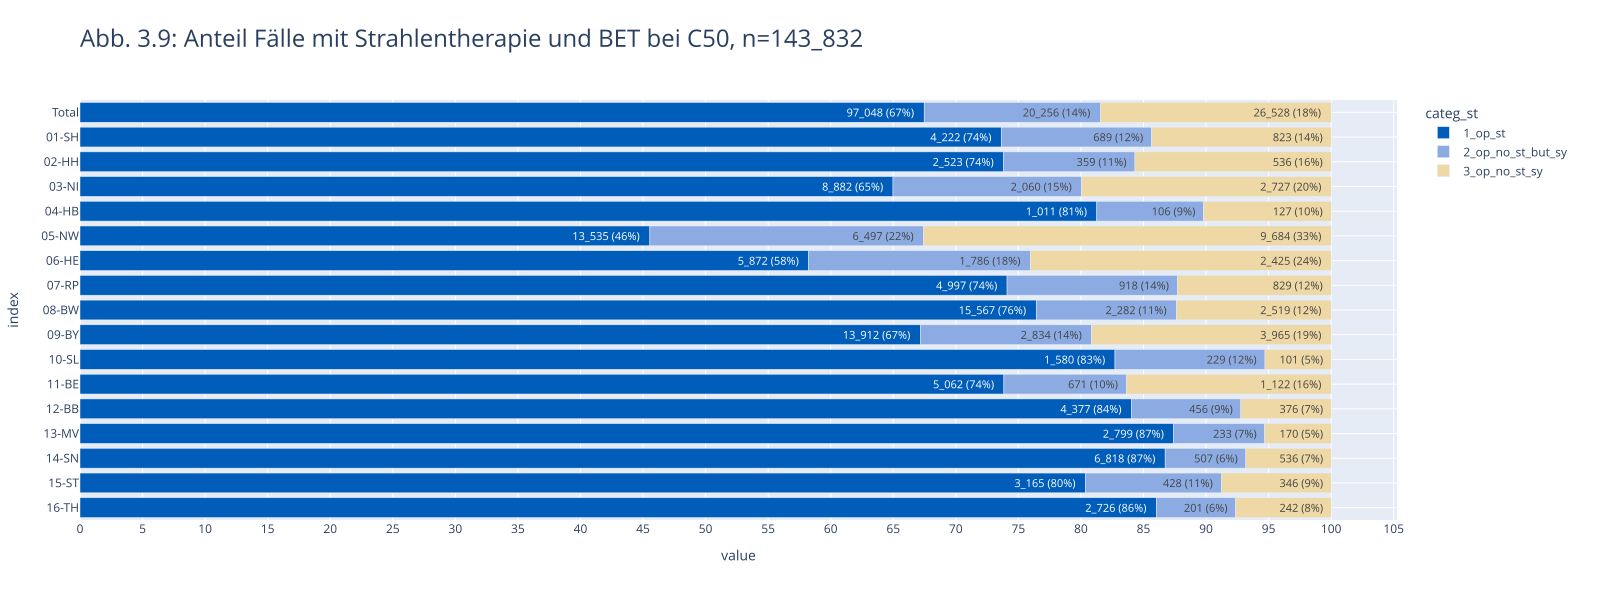

In [15]:
_filters = [
    FILTERS_DY_DELAY,
    FILTERS_C50,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_BET,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on ops.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_st = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        any_value(
        case
            when z_tum_st_count > 0 then '1_op_st'
            when z_tum_sy_count > 0 then '2_op_no_st_but_sy'
            when z_tum_st_count + z_tum_sy_count = 0 then '3_op_no_st_sy'
            else 'U' end
        ) as categ_st,
    from Tumor tum
    join OPS ops on ops.z_tum_id = tum.z_tum_id
    where {_filter}
    group by tum.z_tum_id, z_kkr_label,
""")

pls.plot_stacked_bars(
    db_st.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title= "Abb. 3.9: Anteil Fälle mit Strahlentherapie und BET bei C50"
)
# todo BET filter prüfen

### <a id='toc1_4_6_'></a>[Fehlende Angaben zur systemischen Therapie bei erwarteter systemischer Therapie (akute Leukämien und hochmaligne Lymphome, Kolonkarzinom Stadium III)](#toc0_)
Bei akut verlaufenden Leukämien und Lymphome (akute myeloide und lymphatische Leukämie, diffuses großzelliges B-Zell-Lymphom, follikuläres Lymphom Grad IIIb) liegen bundesweit in 23% (nach Bundesländern: 9%-55%) keine Angaben zu einer systemischen Therapie vor. In der überwiegenden Mehrzahl dieser Fälle ist auch keine andere Therapie dokumentiert, dies betrifft bundesweit insgesamt 18% der Fälle. 


Beim Kolonkarzinom im Stadium III (regionäre Lymphknotenbeteiligung) liegen bundesweit in 54% (nach Bundesländern:42%-62%) keine Angaben zu einer systemischen Therapie vor. In der überwiegenden Mehrzahl dieser Fälle ist eine andere Therapie dokumentiert, nur in 11% der Fälle ist keine Therapie dokumentiert.

> [!NOTE]
> (Stadium III)
>
> Kategorien:
>   - `1_sy` - systemische Therapie
>   - `2_no_sy_but_other` - keine systemische Therapie, aber andere Therapie
>   - `3_no_treat` - keine Therapie

<!-- START_TOKEN -->

n = 3_241_401                                                      (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:                     n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')]:    n = 38_768   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine DCO]:                                          n = 37_488   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [kein M1]:                                            n = 37_461   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:                      n = 27_653   (0.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')
and not z_is_dco
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

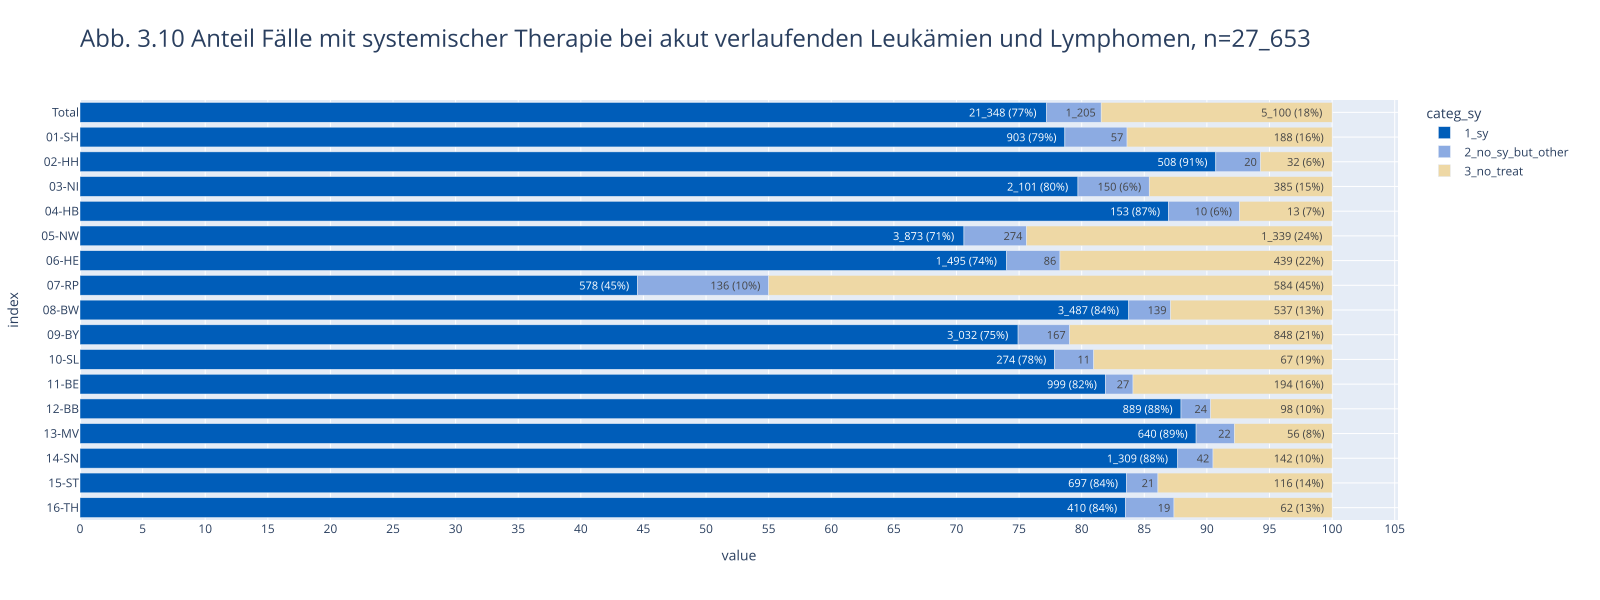

In [16]:
_filters = [
    FILTERS_DY_DELAY,
    ("z_icd10 in ('C91.0', 'C92.0', 'C83.3', 'C82.4')", ""),
    FILTERS_NO_DCO,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)


db_sy = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        case 
            when z_tum_sy_count > 0 then '1_sy'
            when z_tum_st_count + z_tum_op_count > 0 then '2_no_sy_but_other'
            when z_tum_op_count + z_tum_st_count + z_tum_sy_count = 0 then '3_no_treat'
            else 'U'
            end as categ_sy,
    from Tumor tum
    where {_filter}
""")

pls.plot_stacked_bars(
    db_sy.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.10 Anteil Fälle mit systemischer Therapie bei akut verlaufenden Leukämien und Lymphomen",
)

<!-- START_TOKEN -->

n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2023 ohne letzte 6m]:   n = 2_633_644  (81.3%) ░░░░░░████████████████████████
└ [ICD10 C18]:                       n = 135_471   (4.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [keine DCO]:                       n = 131_038   (4.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 107_658   (3.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 95_755   (3.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [pN in (1,2)]:                      n = 23_730   (0.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
Diagnosedatum between '2020-01-01' and '2023-06-30'
and z_icd10_3d in ('C18')
and not z_is_dco
and ifnull(z_m_pc_1,'') <> '1'
and ifnull(z_period_diag_death_day,181) >= 180
and left(z_n_p_1,1) in ('1','2')
```

</details>

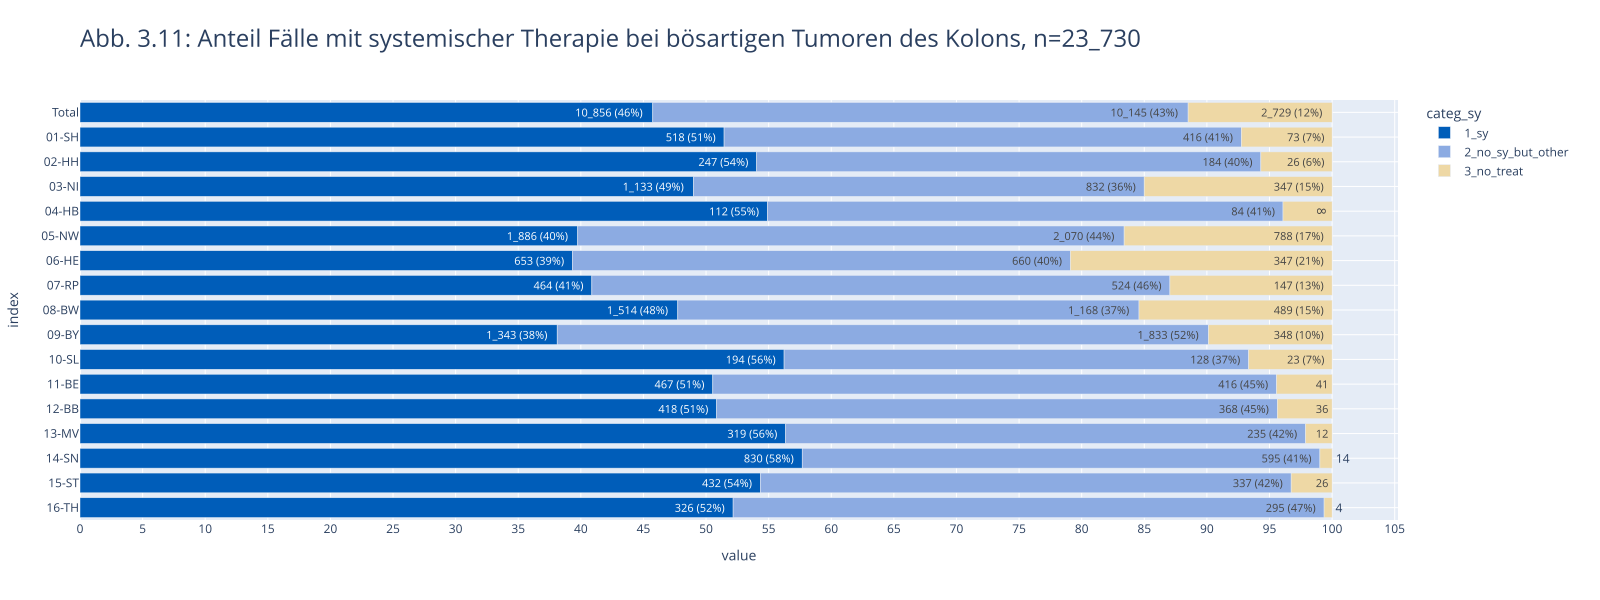

In [17]:
_filters = [
    FILTERS_DY_DELAY,
    ("z_icd10_3d in ('C18')", "ICD10 C18"),
    FILTERS_NO_DCO,
    FILTERS_NO_M1,
    FILTERS_NO_180D_DEAD,
    ("left(z_n_p_1,1) in ('1','2')","pN in (1,2)"),
    # FILTERS_TP,
    # FILTERS_AGE_LT_80,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_db = con.sql(f"""--sql
    select
        --tum.z_tum_id,
        z_kkr_label,
        case 
            when z_tum_sy_count > 0 then '1_sy'
            when z_tum_st_count + z_tum_op_count > 0 then '2_no_sy_but_other'
            when z_tum_op_count + z_tum_st_count + z_tum_sy_count = 0 then '3_no_treat'
            else 'U'
            end as categ_sy,
    from Tumor tum
    where {_filter}
""")

pls.plot_stacked_bars(
    _db.to_df(),
    show_total=True,
    relative=True,
    normalize=True,
    orientation="h",
    show_pct_bar=True,
    title="Abb. 3.11: Anteil Fälle mit systemischer Therapie bei bösartigen Tumoren des Kolons",
)

### <a id='toc1_4_7_'></a>[Abstand zwischen Diagnose und erster Operation](#toc0_)
Der mediane Abstand zwischen Diagnose und erster Operation lag bei 26 Tagen (nach Bundesländern: 7-31 Tage).


<!-- START_TOKEN -->

count: distinct z_tum_id
---
n = 3_241_401                   (100.0%) ██████████████████████████████
└ [DJ 2020-2023]: n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [nur erste OP]: n = 1_290_573  (39.8%) ░░░░░░░░░░░░░░░░░░░███████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2023
and z_op_order = 1
```

</details>

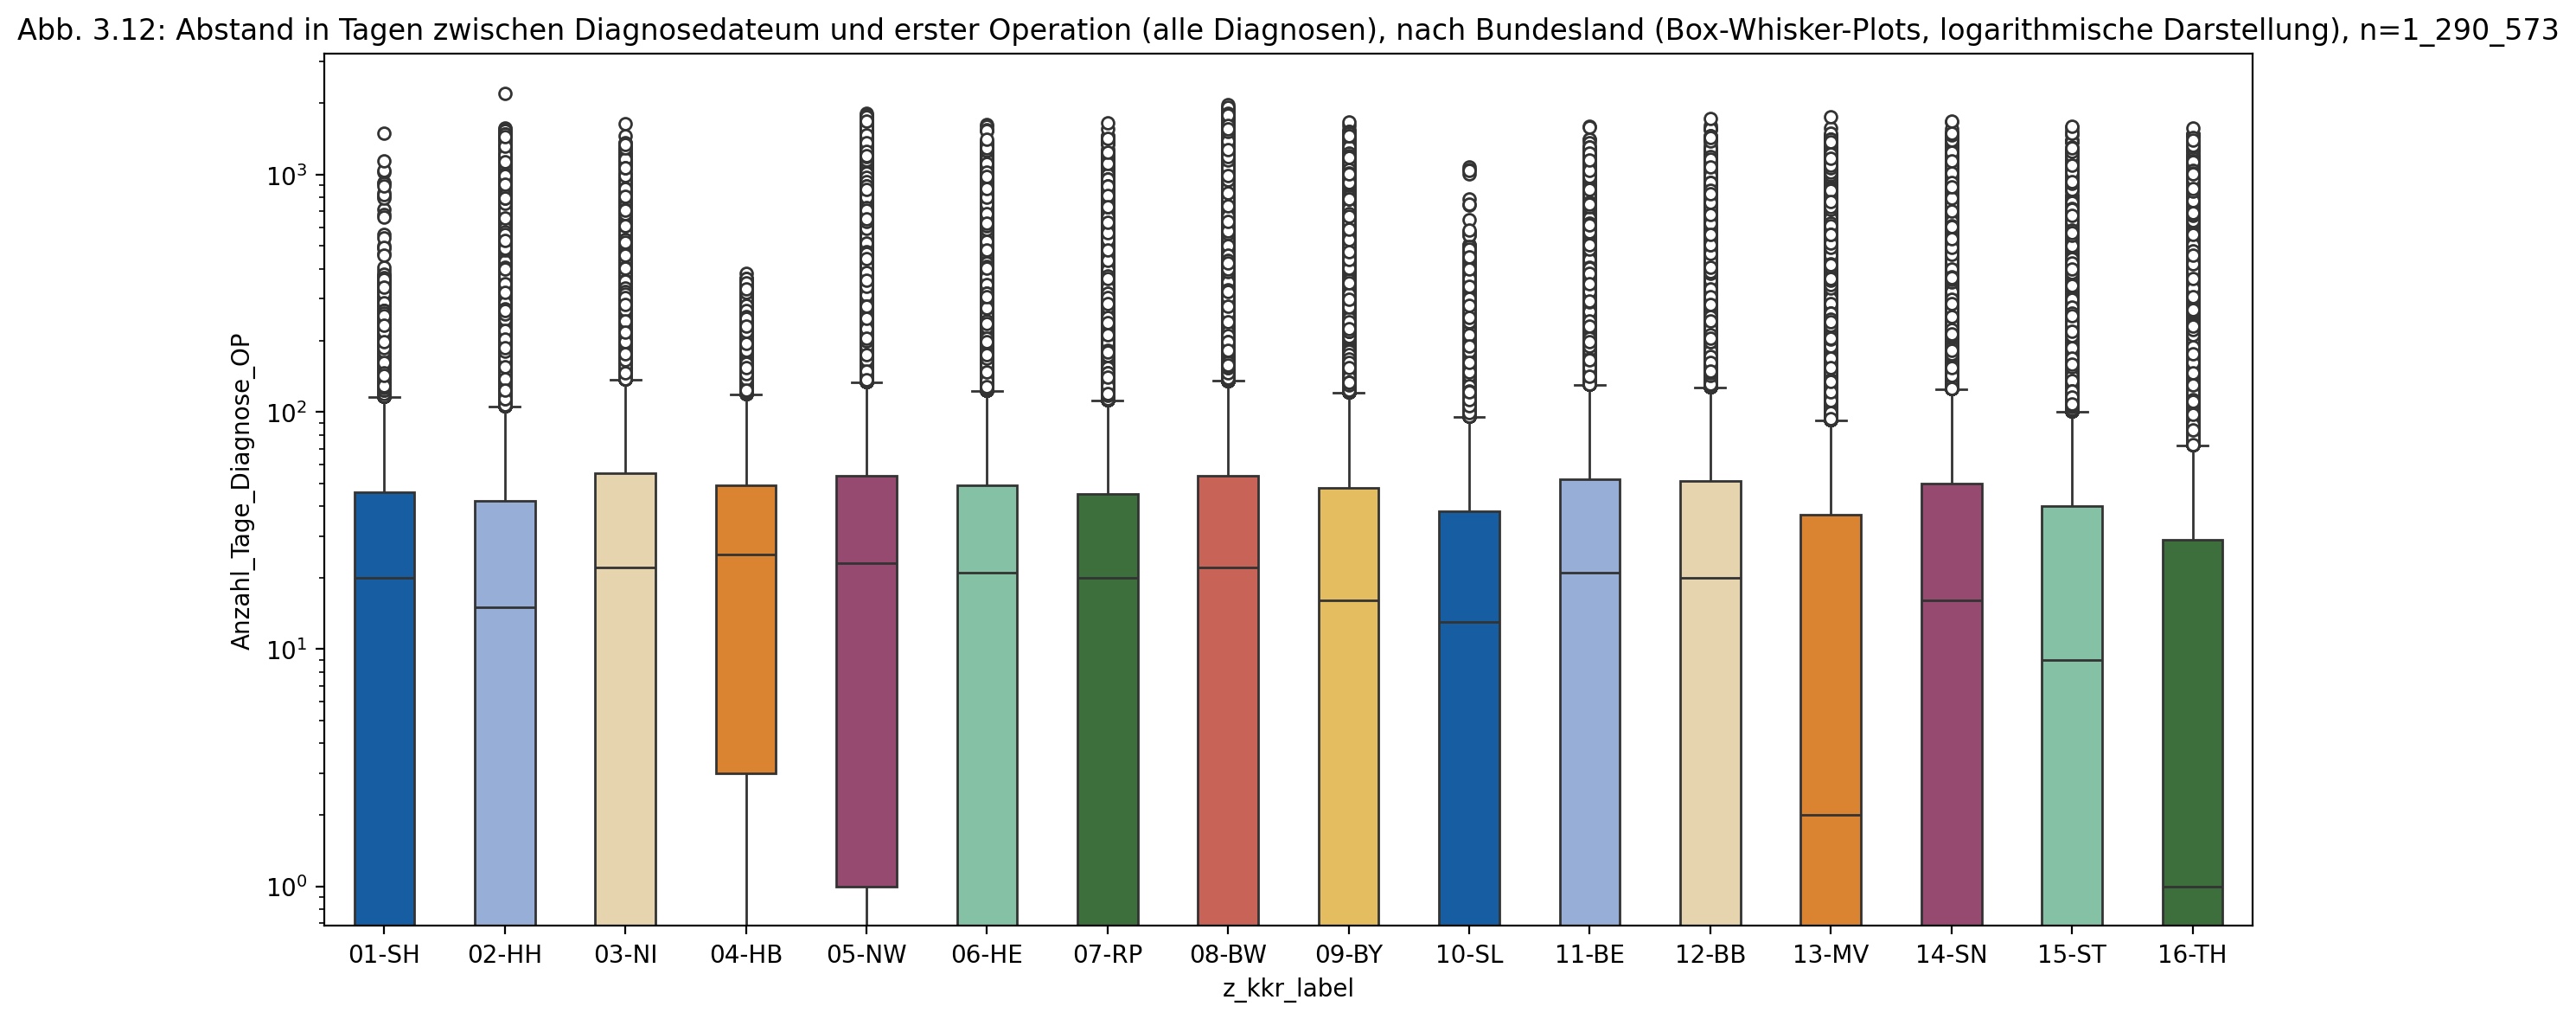


column (n = 1_290_573)  |     notnull     | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std  |  cv 
------------------------+-----------------+------+-------+------+--------+-------+-------+-------+-------+-------+-----
Anzahl_Tage_Diagnose_OP | 1_271_631 (98%) | -304 |   -34 | 0.00 |  19.00 | 47.54 | 49.00 |   122 | 2_204 | 98.96 | 2.08


item (n = 1_290_573) |  count  | min  | lower | q25  | median | mean  |  q75  | upper |  max  |  std   |  cv 
---------------------+---------+------+-------+------+--------+-------+-------+-------+-------+--------+-----
01-SH                |  44_153 |    0 |     0 | 0.00 |  20.00 | 39.21 | 46.00 |   115 | 1_498 |  59.89 | 1.53
02-HH                |  26_895 |    0 |     0 | 0.00 |  15.00 | 45.86 | 42.00 |   105 | 2_204 | 107.44 | 2.34
03-NI                |  92_380 |    0 |     0 | 0.00 |  22.00 | 47.08 | 55.00 |   137 | 1_635 |  76.37 | 1.62
04-HB                |   9_001 |    0 |     0 | 3.00 |  25.00 | 42.04 | 49.00 |   118 |

In [18]:

_filters = [
    FILTERS_DY,
    ("z_op_order = 1", "nur erste OP"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df=con.sql(f"""--sql
    select 
        z_kkr_label,
        Anzahl_Tage_Diagnose_OP,
    from Tumor tum
    join OP op on op.z_tum_id = tum.z_tum_id
    where {_filter}
""")
# _df=con.sql("""--sql
#     select 
#         l.kkr as z_kkr_label,
#         Anzahl_Tage_Diagnose_OP,
#     from OP op
#     left join dim_lieferregister l on l.code = z_kkr
#     where z_op_order = 1
# """)
# _ = pls.plot_box_large(
#     _df.project("Anzahl_Tage_Diagnose_OP").to_df(),
#     height=150,
#     summary=False,
#     use_log=False,
#     caption="Abb. 3.12: Abstand Diagnose OP",
# )
_ = pls.plot_boxes_large(
    _df.to_df(),
    use_log=True,
    title="Abb. 3.12: Abstand in Tagen zwischen Diagnosedateum und erster Operation (alle Diagnosen), nach Bundesland (Box-Whisker-Plots, logarithmische Darstellung)",
)

### <a id='toc1_4_8_'></a>[Informationen zum Krankheitsverlauf](#toc0_)
#### <a id='toc1_4_8_1_'></a>[Nach Brustkrebs](#toc0_)
Für Patientinnen mit Brustkrebsdiagnosen und Operation ohne Residualtumor (R0) aus  den Jahren 2020/2021 ist bis Ende 2023 in 5% der Fälle (nach Bundesländern: 2%-8%, 4 Bundesländer ohne Angaben) ein Verlaufsereignis dokumentiert. In gut zwei Drittel dieser Fälle betraf dies Fernmetastasen, teilweise in Kombination mit Lokalrezidiven und Lymphknotenmetastasen. Für diese Auswertungen wurden verschiedene Variablen genutzt, Abbildung 3.6.1.2 zeigt alle Kombinationen der relevanten Ausprägungen. Es wurde kein Mindestabstand zum Diagnosedatum festgelegt. 

> [!NOTE]
> Zeitraum bis Ende 2023 nach Brustkrebsdiagnose in 2020/2021
> 
> Kategorien:
>   - `1_fo_relapse` - Rezidiven
>   - `2_fo_relapse_tnm` - Rezidiven nach TNM
>   - `3_no_relapse` - Kein Rezidiv

<!-- START_TOKEN -->

count: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2021]:                  n = 1_495_715  (46.1%) ░░░░░░░░░░░░░░░░░█████████████
└ [ICD10 C50]:                       n = 157_980   (4.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                         n = 146_979   (4.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [Residualstatus R0]:                n = 89_812   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 89_461   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2021
and z_icd10_3d = 'C50'
and ifnull(z_m_pc_1,'') <> '1'
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

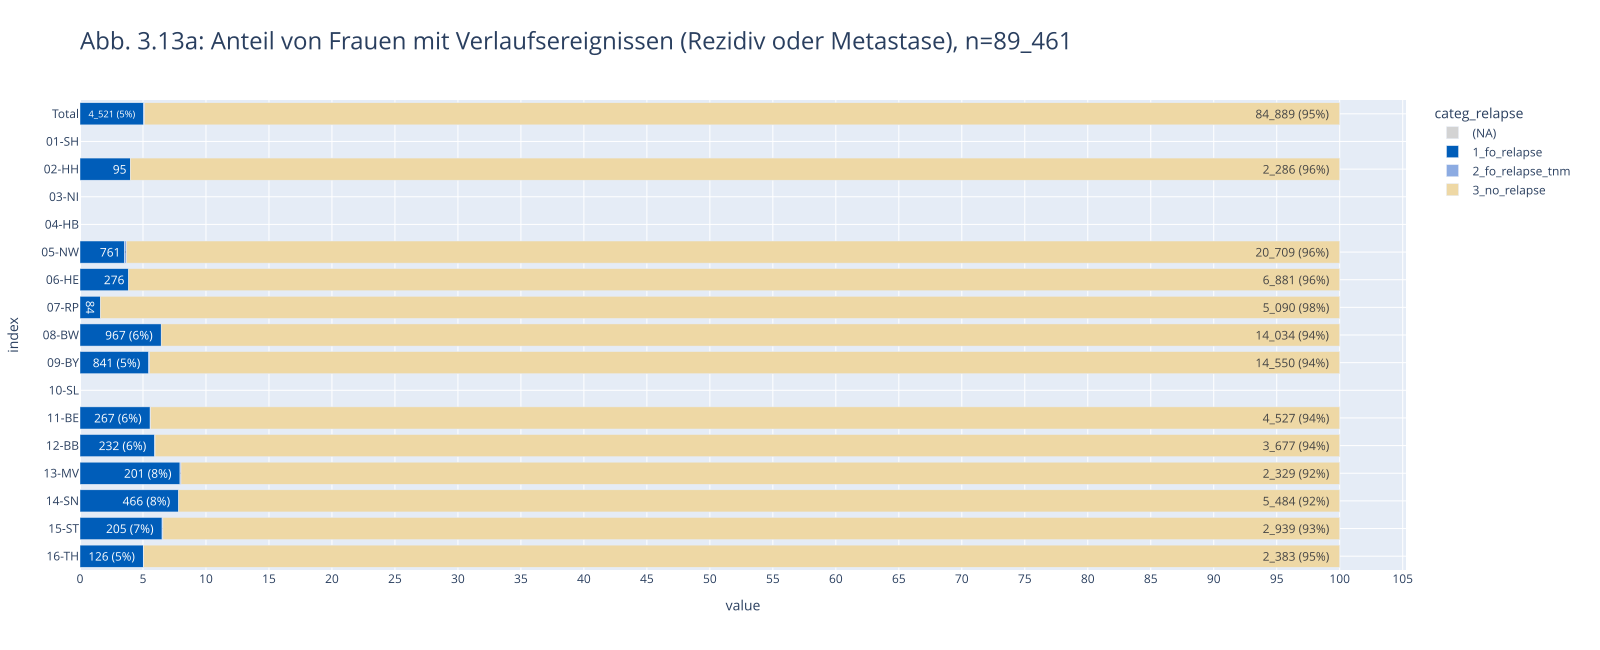

In [19]:
# FILTER = f"z_dy between 2020 and 2021 and {FILTER_M0} and {FILTER_R0} and {FILTER_NO_180D_DEAD}"

_filters = [
    ("z_dy between 2020 and 2021", "DJ 2020-2021"),
    FILTERS_C50,
    # FILTERS_OP_COUNT,
    # FILTERS_M0,
    FILTERS_NO_M1,
    FILTERS_R0,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id
                ,z_dy
                ,z_icd10_3d
                ,z_pat_id
                ,z_kkr_label
                ,z_m_pc_1
                ,Lokale_Beurteilung_Residualstatus
                ,z_period_diag_death_day
                ,fol.Gesamtbeurteilung_Tumorstatus
                ,fol.Verlauf_Lokaler_Tumorstatus
                ,fol.Verlauf_Tumorstatus_Lymphknoten
                ,fol.Verlauf_Tumorstatus_Fernmetastasen
                ,r_Symbol
                ,T, N, M
                ,(fol.FolgeereignisId is not null) as has_fo
                
                -- nulls -> false to get intersections later
                ,coalesce((Gesamtbeurteilung_Tumorstatus ==  'Y'), false) as has_gesamt
                ,coalesce((Verlauf_Lokaler_Tumorstatus == 'R'), false) as has_lokal
                ,coalesce((Verlauf_Tumorstatus_Lymphknoten == 'R'), false) as has_lymph
                ,coalesce((Verlauf_Tumorstatus_Fernmetastasen == 'R'), false) as has_fm
                -- extended
                ,(r_Symbol is not null) as has_r_symbol

                ,(left(T,1) in ('1','2','3','4')) as has_t2plus
                ,(left(N,1) in ('1','2','3','4')) as has_n2plus
                ,(left(M,1) in ('1','2','3','4')) as has_m2plus
                ,(
                    z_t_p_1 in ('0','is')
                    and z_n_p_1 in ('0')
                    and y_Symbol_p is not null
                ) as has_rel3,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter}
    ),
    t2 as (
        select  z_tum_id
                ,any_value(z_pat_id) as z_pat_id
                ,any_value(z_m_pc_1) as z_m_pc_1
                ,any_value(z_icd10_3d) as z_icd10_3d
                ,any_value(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_fo) as has_fo
                ,max(has_gesamt) as has_gesamt
                ,max(has_lokal) as has_lokal
                ,max(has_lymph) as has_lymph
                ,max(has_fm) as has_fm
                ,max(has_r_symbol) as has_r_symbol
                ,max(has_t2plus) as has_t2plus
                ,max(has_n2plus) as has_n2plus
                ,max(has_m2plus) as has_m2plus
                ,max(has_rel3) as has_rel3
                ,max(has_gesamt or has_lokal or has_lymph or has_fm) as has_rel1
                ,max(has_r_symbol and (has_t2plus or has_n2plus or has_m2plus)) as has_rel2
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  t2.*
                ,pat.Verstorben
                ,case
                    --when has_rel3 then '1_patho_relapse'
                    when has_rel1 then '1_fo_relapse'
                    when has_rel2 then '2_fo_relapse_tnm'
                    else '3_no_relapse'
                end as categ_relapse
        from t2
        join Patient pat on pat.oBDS_RkiPatientId = t2.z_pat_id
    )
    select * from t3
""")

# tbl.descr_db(db_rez, "relapse")
pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="C50_tum_relapse",
    height=650,
    width=1600,
    # color_palette="Pastel",
    kkr_col="z_kkr_label",
    title="Abb. 3.13a: Anteil von Frauen mit Verlaufsereignissen (Rezidiv oder Metastase)",
    # dropna=True,
)

Abb. 3.13b: Verteilung der Verlaufsereignisse bis Ende 2023 nach Brustkrebsdiagnose in 2020/2021 (inkl. aller Kombinationen)

n = 89_461 | n(true) = 4_521


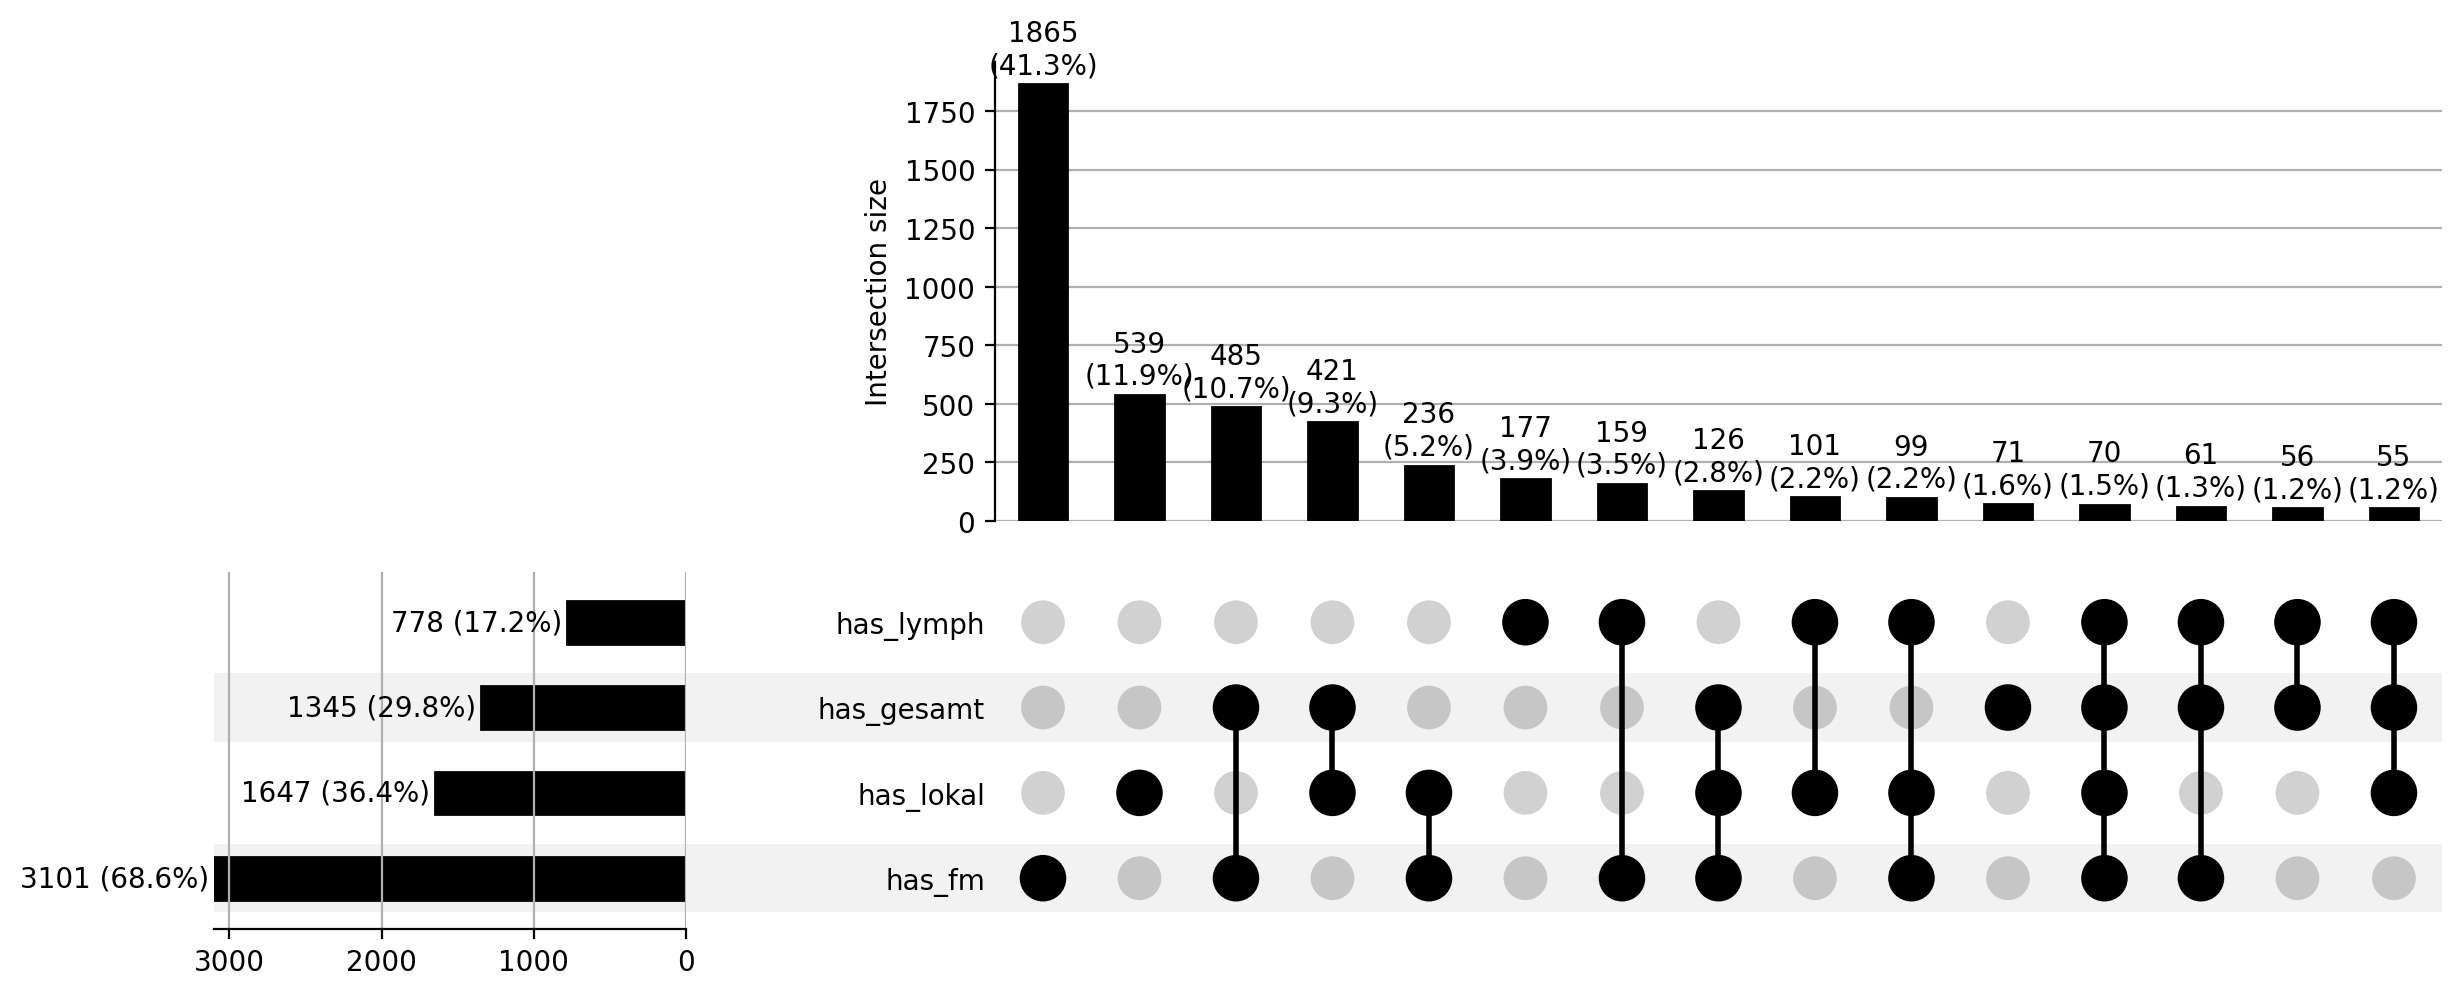

In [20]:
df_rez_upset = db_rez.project("has_gesamt, has_lokal, has_lymph, has_fm").to_df()#.astype(int)
pls.plot_upset(df_rez_upset, include_false_subsets=False,)

#### <a id='toc1_4_8_2_'></a>[Nach Darmkrebs](#toc0_)
Für Personen mit Darmkrebsdiagnosen und Operation ohne Residualtumor (R0) aus den Jahren 2020/2021 ist bis Ende 2023 in 10% der Fälle (nach Bundesländern: 3%-14%, 4 Bundesländer ohne Angaben) ein Verlaufsereignis dokumentiert. In gut zwei Drittel dieser Fälle betraf dies Fernmetastasen, teilweise in Kombination mit Lokalrezidiven und Lymphknotenmetastasen. Für diese Auswertungen wurden verschiedene Variablen genutzt, Abbildung 3.6.2.2 zeigt alle Kombinationen der relevanten Ausprägungen. Es wurde kein Mindestabstand zum Diagnosedatum festgelegt. 


<!-- START_TOKEN -->

count: distinct z_tum_id
---
n = 3_241_401                                    (100.0%) ██████████████████████████████
└ [DJ 2020-2021]:                  n = 1_495_715  (46.1%) ░░░░░░░░░░░░░░░░░█████████████
└ [ICD10 C18-C20]:                   n = 114_553   (3.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [kein M1]:                          n = 94_460   (2.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [Residualstatus R0]:                n = 49_856   (1.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [keine Verstorbenen < 180 Tage]:    n = 46_861   (1.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2021
and z_icd10_3d in ('C18', 'C19', 'C20')
and ifnull(z_m_pc_1,'') <> '1'
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
and ifnull(z_period_diag_death_day,181) >= 180
```

</details>

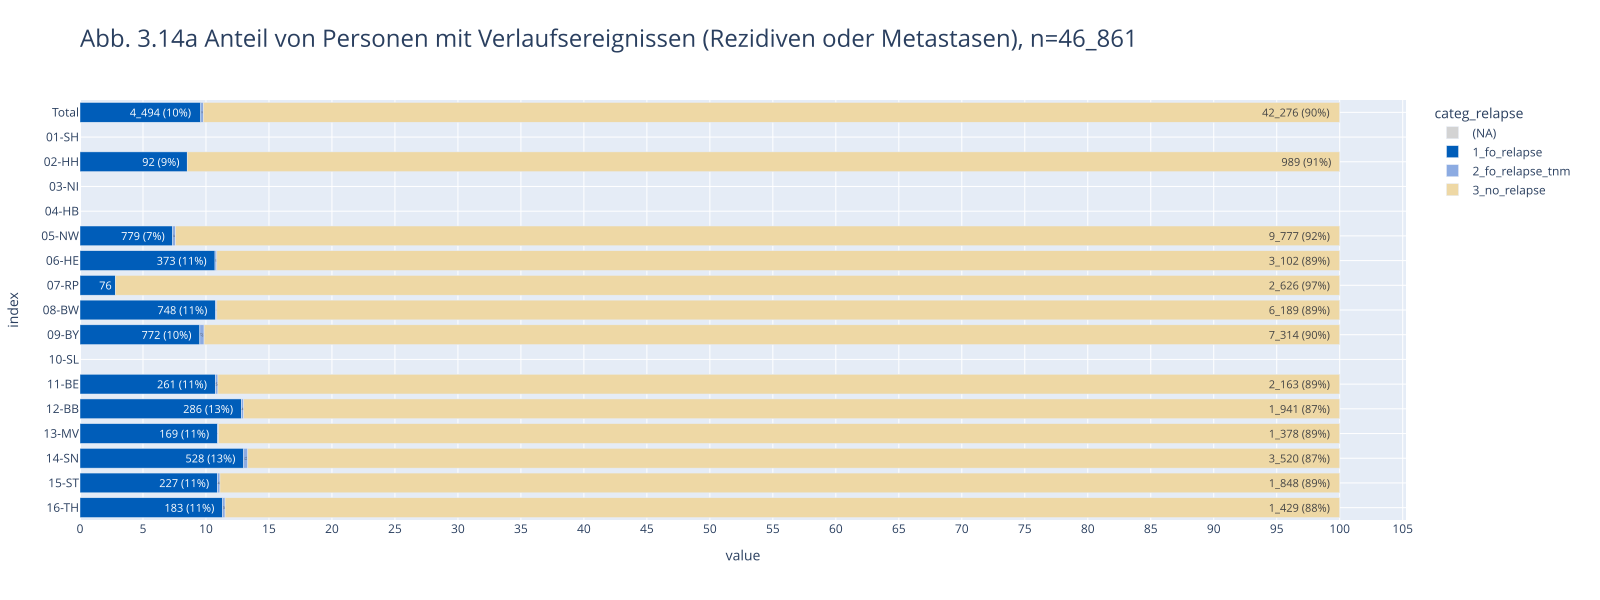

In [21]:

_filters = [
    ("z_dy between 2020 and 2021", "DJ 2020-2021"),
    FILTERS_C18C20,
    FILTERS_NO_M1,
    FILTERS_R0,
    FILTERS_NO_180D_DEAD,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OP op on op.z_tum_id = tum.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id,
                z_dy,
                z_icd10_3d,
                z_pat_id,
                z_kkr_label,
                z_m_pc_1,
                Lokale_Beurteilung_Residualstatus,
                z_period_diag_death_day,
                fol.Gesamtbeurteilung_Tumorstatus,
                fol.Verlauf_Lokaler_Tumorstatus,
                fol.Verlauf_Tumorstatus_Lymphknoten,
                fol.Verlauf_Tumorstatus_Fernmetastasen,
                r_Symbol,
                T, N, M,
                (fol.FolgeereignisId is not null) as has_fo,
                --True as has_fo_gt_180,
                (z_period_diag_fo_day > 180) as has_fo_gt_180,
                
                -- nulls -> false to get intersections later
                coalesce((Gesamtbeurteilung_Tumorstatus ==  'Y'), false) and has_fo_gt_180 as has_gesamt,
                coalesce((Verlauf_Lokaler_Tumorstatus == 'R'), false) and has_fo_gt_180 as has_lokal,
                coalesce((Verlauf_Tumorstatus_Lymphknoten == 'R'), false) and has_fo_gt_180 as has_lymph,
                coalesce((Verlauf_Tumorstatus_Fernmetastasen == 'R'), false) and has_fo_gt_180 as has_fm,
                -- extended
                (r_Symbol is not null) as has_r_symbol,

                (left(T,1) in ('1','2','3','4')) as has_t2plus,
                (left(N,1) in ('1','2','3','4')) as has_n2plus,
                (left(M,1) in ('1','2','3','4')) as has_m2plus,
                (
                    z_t_p_1 in ('0','is')
                    and z_n_p_1 in ('0')
                    and y_Symbol_p is not null
                ) as has_rel3,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter}
    ),
    t2 as (
        select  z_tum_id
                ,any_value(z_pat_id) as z_pat_id
                ,any_value(z_m_pc_1) as z_m_pc_1
                ,any_value(z_icd10_3d) as z_icd10_3d
                ,any_value(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_fo) as has_fo
                ,max(has_gesamt) as has_gesamt
                ,max(has_lokal) as has_lokal
                ,max(has_lymph) as has_lymph
                ,max(has_fm) as has_fm
                ,max(has_r_symbol) as has_r_symbol
                ,max(has_t2plus) as has_t2plus
                ,max(has_n2plus) as has_n2plus
                ,max(has_m2plus) as has_m2plus
                ,max(has_rel3) as has_rel3
                ,max(has_gesamt or has_lokal or has_lymph or has_fm) as has_rel1
                ,max(has_r_symbol and (has_t2plus or has_n2plus or has_m2plus)) as has_rel2
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  t2.*
                ,pat.Verstorben
                ,case
                    --when has_rel3 then '1_patho_relapse'
                    when has_rel1 then '1_fo_relapse'
                    when has_rel2 then '2_fo_relapse_tnm'
                    else '3_no_relapse'
                end as categ_relapse
        from t2
        join Patient pat on pat.oBDS_RkiPatientId = t2.z_pat_id
    )
    select * from t3
""")

# tbl.descr_db(db_rez, "relapse")
# db_rez_c50 = db_rez.filter(f"{FILTER_C50}")


# db_rez_c18 = db_rez.filter("z_icd10_3d in ('C18','C19','C20')")
pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="C18-C20_tum_relapse",
    height=600,
    width=1600,
    kkr_col="z_kkr_label",
    title="Abb. 3.14a Anteil von Personen mit Verlaufsereignissen (Rezidiven oder Metastasen)"
)

Abb. 3.14b Verteilung der Verlaufsereignisse bis Ende 2023 nach Darmkrebsdiagnose 2020/2021 (inkl. aller Kombinationen)

n = 46_861 | n(true) = 4_494


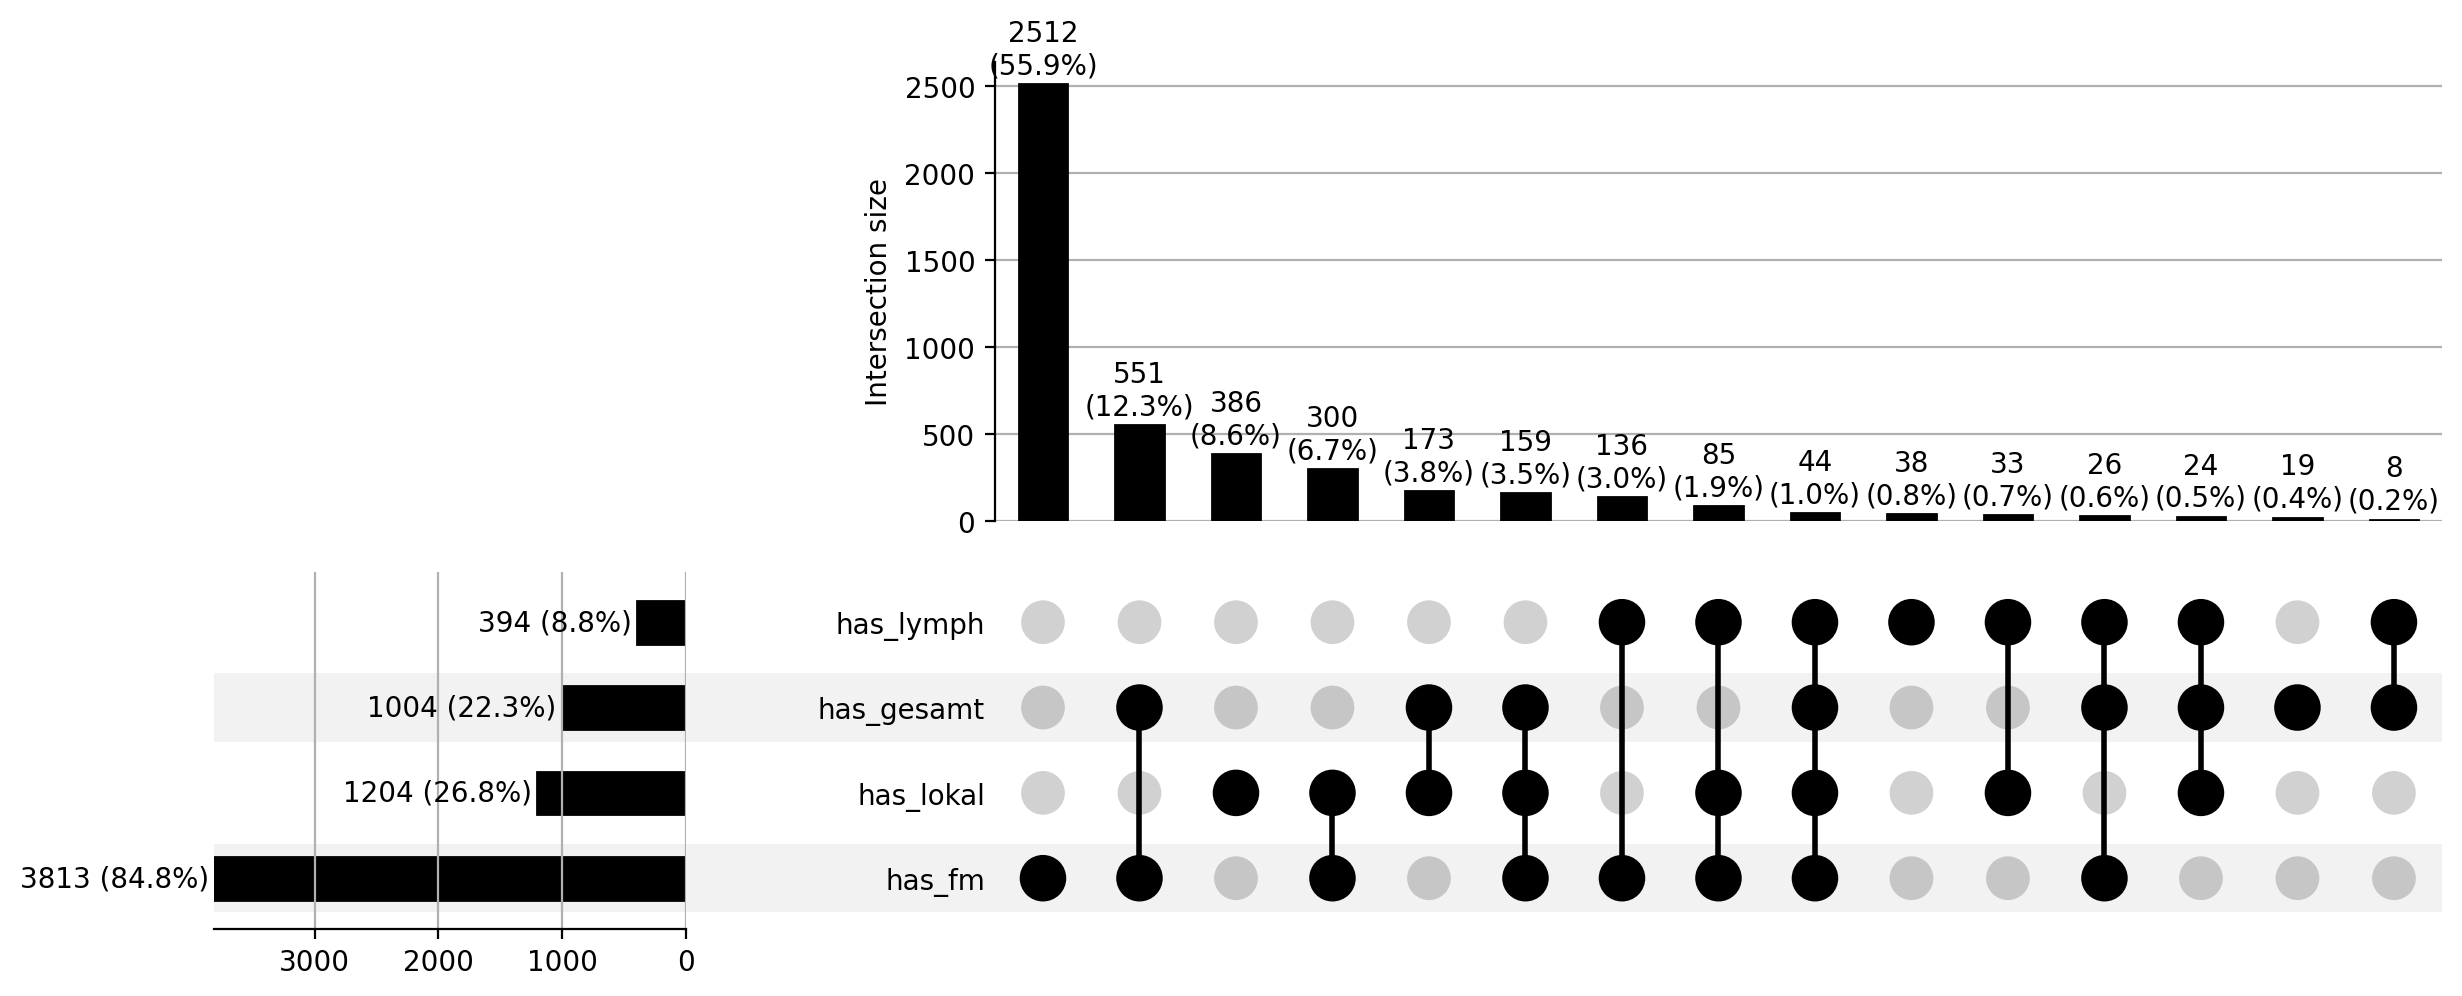

In [22]:
df_rez_upset = db_rez.project("has_gesamt, has_lokal, has_lymph, has_fm").to_df()
pls.plot_upset(df_rez_upset, include_false_subsets=False,)
# todo OK fo erst bei > 3m

### <a id='toc1_4_9_'></a>[Einordnung der Ergebnisse zur Datenqualität](#toc0_)

Bei der Interpretation der Auswertungen sind folgende Aspekte zu berücksichtigen:

Bei Krebsregisterdaten ist grundsätzlich nicht zu erwarten, dass die Qualität von Daten aus klinischen, z.B.  Zulassungsstudien erreicht werden kann. Trotz Meldepflicht können die Register eine vollständige und fehlerfreie Meldung aller klinisch verfügbaren Informationen (soweit im oBDS abbildbar) nicht erzwingen.
Viele Methoden, die in Studien zur Steigerung der Datenqualität zur Anwendung kommen (Datenaudits, Validierung anhand von Krankenakten) kommen in bevölkerungsbezogenen Krebsregistern nicht oder nur bedingt zum Einsatz. Auch Plausibilitätsprüfungen bei der Dateneingabe bzw. beim Export aus Krankenhausinformationssystemen können nur einen gewissen Teil fehlerhafte Meldungen abfangen, oft ergeben sich Widersprüche aus Meldungen unterschiedlicher Einrichtungen zum gleichen Erkrankungsfall. 

Unvollständige Daten, z.B. zum Tumorstadium, können sich auch aus der klinischen Situation ergeben: so wird auf umfassende Untersuchungen zum Staging im klinischen Alltag im bestimmten Fällen, aufgrund des gesundheitlichen Zustands oder auf Wunsch der Betroffenen, verzichtet, vor allem, wenn sich aus den Ergebnissen absehbar keine therapeutischen Konsequenzen ergeben würden. 

Bezüglich der Daten zur Therapie und zum Krankheitsverlauf kann in den Krebsregisterdaten nicht zwischen nicht gemeldeten und nicht durchgeführten Therapien bzw. stattgefunden Ereignissen unterschieden werden. Es gibt für die Meldenden außerdem keine Möglichkeit, den Grund für eine Abweichung von etablierten Therapieschemata bzw. Leitlinien im OBDS zu dokumentieren. 

In den obigen Auswertungen wurden exemplarische Fallkonstellationen ausgewählt, in denen (mangels gleichwertiger Alternativen) eine bestimmte Therapie in der Regel bzw. nach aktuellen Leitlinien zu erwarten wäre (z.B. Operationen bei Brustkrebs im Stadium I-III). Im klinischen Alltag ist aus den genannten Gründen (z.B. schwere Begleiterkrankungen) jedoch nicht davon auszugehen, dass diese Therapien in allen Fällen durchgeführt werden.  Es ist vielmehr damit zu rechnen, dass sich in einem gewissen Anteil der Fälle Behandelnde und/oder Betroffene begründet gegen eine bestimmte Behandlung entschieden haben. Die je nach Diagnose und Therapieart gefundenen Anteile und die teilweise große Heterogenität zwischen den Bundesländern spricht jedoch dafür, dass tumorbezogene Therapien derzeit noch nicht vollständig in den Krebsregistern erfasst werden. Der in allen Registern gefundene hohe Anteil von Patientinnen und Patienten ohne gemeldete bzw. dokumentierte systemische Therapie bei bösartigen Tumoren des Kolons im Stadium III (Lymphknotenbefall)  könnte aber auch darauf hindeuten, dass diese Therapie in einem relevanten Anteil der Fälle entgegen der Leitlinienempfehlungen nicht durchgeführt wird.

Der Anteil nicht erfasster Therapien lässt sich aus den Ergebnissen aus den genannten gründen nicht direkt ableiten.  Es ist daher auch nicht auszuschließen, dass die gezeigten Unterschiede zwischen den Bundesländern bezüglich nicht gemeldeter (aber erwarteter) Therapien zum Teil auch reale Unterschiede in der Versorgung abbilden. Außerdem sind die hier gezeigten Ergebnisse für ausgewählte Diagnosen nicht ohne weiteres auf andere Entitäten übertragbar.

Insgesamt ist allerdings davon auszugehen, dass die Erfassung von inzidenter Krebsdiagnosen in den Krebsregistern derzeit noch vollständiger gelingt als die Erfassung der Therapien. Dies ist auch dadurch bedingt, dass pathologische Institute direkt an das Krebsregister melden, da sie zu den „Krebserkrankungen diagnostizierenden“ Einrichtungen gehören. Eine pathologische Befundmeldung reicht in vielen Fällen aus, um im Krebsregister Angaben zur Diagnose differenziert (nach Lokalisation, Histologie und Tumorstadium) zu dokumentieren, bei Fehlen einer klinischen Meldung wären dann allerdings keine Angaben zur Therapie vorhanden. Umgekehrt ist es bei Fehlen einer pathologischen Meldung und Vorhandensein einer klinischen Meldung in der Regel zu erwarten, dass die wesentlichen Informationen aus dem pathologischen Befund (z.B. zu Histologie und pathologischem Tumorstadium) über die klinische Meldung an das Register übermittelt werden. Da im Datensatz des ZfKD Informationen von verschiedenen meldenden Einrichtungen zusammengefasst sind („Best-of“), ist in den Daten nicht direkt erkennbar, welche Meldungstypen den Angaben zugrunde liegen. Ein Hinweis auf eine fehlende oder unvollständige klinische Meldung bei vorhandener pathologischer Meldung kann die relativ häufig vorhandene gültige Angabe zum pathologischem T-Stadium („pT“) bei fehlenden Angaben zu einer (zur Lokalisation des Tumors passenden) Operation sein. In Einzelfällen kann es allerdings zumindest beim Melanom und beim Darmkrebs vorkommen, dass der Tumor im Rahmen einer ursprünglich diagnostischen Prozedur im Ganzen entfernt werden kann und daher auch ohne Operation eine pathologisches T-Stadium bestimmbar ist, dies könnte einen Teil der Fälle mit pT ohne Operation erklären.

Die in einigen Registern deutlich nach unten abweichenden medianen Abstände zwischen Diagnose und erster Operation lassen auf Unterschiede zwischen den Registern bei der Definition des Diagnosedatums oder unterschiedliches Meldeverhalten zu dieser Variable schließen. 

Derzeit kann die Vollständigkeit der Erfassung bestimmter Ereignisse im Krankheitsverlauf noch nicht beurteilt werden. Zum einen ist die Beobachtungszeit ab Erstdiagnose noch relativ kurz (maximal knapp vier Jahre), zum anderen existiert derzeit keine einzelne Datenquelle, mit denen sich an den Krebsregisterdaten ermittelten diagnosespezifischen Rezidiv- und Metastasierungsraten validieren lassen. 

Das ZfKD plant eine entsprechende Evaluation in den nächsten zwei Jahren anhand einer ausführlichen Literaturrecherche für ausgewählte Diagnosen, ggf. in Abhängigkeit vom Tumorstadium.

Eine gewisse Einschränkung bei der Beurteilung von Rezidiven ergibt sich aus der Definition eines Rezidivs. Ein Rezidiv kann grundsätzlich nur festgestellt werden, wenn zuvor Tumorfreiheit (Remission) bestand. Diese kann grundsätzlich nach einer Operation, Strahlentherapie, systemischen Therapie oder einer Kombination verschiedener Therapieformen erzielt werden. 

Im Datensatz des ZfKD kann Tumorfreiheit durch den R-Status nach Operation (R0), durch ein yT0 während oder nach multimodaler Therapie oder durch die Angabe einer Remission im Krankheitsverlauf abgebildet werden. Da eine Remission im Verlauf in vielen Bundesländern kein meldebegründendes Ereignis darstellt (im Gegensatz zum Lokalrezidiv, einer Metastasierung oder einer Änderung der Therapie) wird in einigen Fällen die Abgrenzung zwischen einem Fortschreiten der Erkrankung (Progression) und einem Rezidiv schwierig sein, vor allem wenn eine Tumorfreiheit nicht primär durch eine Operation erzielt wurde.  Dies gilt vor allem für Neubildungen der blutbildenden und lymphatischen Organe, für die in der Regel werder der R-Status noch das y-TNM zur Verfügung steht. Dazu kommt, dass auch bei operativ behandelten Tumoren nach den Erfahrungen aus den Landeskrebsregistern die Angaben zu  Rezidiven und Progressionen in den klinischen Verlaufsmeldungen häufig inkonsistent sind. 

Mögliche Gründe für unterbliebene oder unvollständige (klinische) Meldungen an die Krebsregister können aus den Daten des ZfKD nicht abgeleitet werden. Bekannt ist, dass die Meldung für nicht auf Krebsbehandlungen spezialisierte Kliniken und vor allem für niedergelassene Ärztinnen und Ärzte um einiges aufwändiger ist als für zertifizierte Tumorzentren und Pathologische Institute. Gerade im Bereich der Niedergelassenen, aber auch in vielen Kliniken ist eine automatisierte Meldung über eine Schnittstelle aus der elektronischen Klinik- oder Praxisdokumentation noch nicht realisiert. Hier liegt es nahe, dass Meldungen an das Krebsregister wegen des hohen Aufwands trotz Meldepflicht im Praxis- oder Klinikalltag häufiger unterbleiben.